In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from utils import save_gif, plot_3d_distribution

# Change to repo root directory (parent of 'analysis' folder)
# In Jupyter, we can use the notebook's directory or go up from current directory
current_dir = Path.cwd()
if current_dir.name == 'analysis':
    # If we're in the analysis folder, go up one level
    repo_root = current_dir.parent
elif 'analysis' in current_dir.parts:
    # If analysis is in the path, find repo root
    idx = current_dir.parts.index('analysis')
    repo_root = Path(*current_dir.parts[:idx])
else:
    # Otherwise, assume we're already at repo root or need to navigate
    repo_root = Path('/Users/svngo/Documents/GitHub/Dicty-Cell-Aggregation-Analysis')

os.chdir(repo_root)
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/svngo/Documents/GitHub/Dicty-Cell-Aggregation-Analysis


In [2]:
# Read CSV, skipping the extra header rows (TrackMate exports have multiple header rows)
# Row 0: actual column names (keep as header)
# Row 1-3: descriptive headers we want to skip
edges_path = 'results/trial_5/highdensity_edges.csv'
spots_path = 'results/trial_5/highdensity_spots.csv'
tracks_path = 'results/trial_5/highdensity_tracks.csv'
edges = pd.read_csv(edges_path, header=0, skiprows=[1, 2, 3])  # Keep row 0 as header, skip rows 1-3
spots = pd.read_csv(spots_path, header=0, skiprows=[1, 2, 3])
tracks = pd.read_csv(tracks_path, header=0, skiprows=[1,2,3])


# 1) Unreverse spot time
tmax = spots['POSITION_T'].max()
fmax = spots['FRAME'].max()
spots['POSITION_T'] = tmax - spots['POSITION_T']
spots['FRAME'] = fmax - spots['FRAME']

# 2) Unreverse edge time
etmax = edges['EDGE_TIME'].max()
edges['EDGE_TIME'] = etmax - edges['EDGE_TIME']

# 3) Swap edge direction so source->target is forward again
edges[['SPOT_SOURCE_ID', 'SPOT_TARGET_ID']] = edges[['SPOT_TARGET_ID', 'SPOT_SOURCE_ID']].to_numpy()

# 4) Unreverse track-level time metadata
ttmax = tracks['TRACK_STOP'].max()
tracks['TRACK_START'], tracks['TRACK_STOP'] = (
    ttmax - tracks['TRACK_STOP'],
    ttmax - tracks['TRACK_START'],
)

# 5) Sort after unreverse (presentation / stable downstream ops)
spots = spots.sort_values(['TRACK_ID', 'POSITION_T']).reset_index(drop=True)
edges = edges.sort_values(['TRACK_ID', 'EDGE_TIME']).reset_index(drop=True)
tracks = tracks.sort_values(['TRACK_ID']).reset_index(drop=True)


print(f"DataFrame shape: {edges.shape}")
print(f"\nColumns: {edges.columns.tolist()}")
edges.head()

DataFrame shape: (551198, 13)

Columns: ['LABEL', 'TRACK_ID', 'SPOT_SOURCE_ID', 'SPOT_TARGET_ID', 'LINK_COST', 'DIRECTIONAL_CHANGE_RATE', 'SPEED', 'DISPLACEMENT', 'EDGE_TIME', 'EDGE_X_LOCATION', 'EDGE_Y_LOCATION', 'EDGE_Z_LOCATION', 'MANUAL_EDGE_COLOR']


,LABEL,TRACK_ID,SPOT_SOURCE_ID,SPOT_TARGET_ID,LINK_COST,DIRECTIONAL_CHANGE_RATE,SPEED,DISPLACEMENT,EDGE_TIME,EDGE_X_LOCATION,EDGE_Y_LOCATION,EDGE_Z_LOCATION,MANUAL_EDGE_COLOR
0,ID8828 → ID8877,0,8877,8828,0.010385,2.168411,0.196958,0.196958,3361.0,282.778894,69.562104,0.0,NaN
1,ID8854 → ID8828,0,8828,8854,0.589797,2.265405,0.364018,0.364018,3362.0,282.882576,69.671212,0.0,NaN
2,ID8806 → ID8854,0,8854,8806,0.395159,2.969275,0.353423,0.353423,3363.0,283.028846,69.713462,0.0,NaN
3,ID8900 → ID8806,0,8806,8900,1.611157,2.954880,0.222725,0.222725,3364.0,283.056624,69.649573,0.0,NaN
4,ID8822 → ID8900,0,8900,8822,0.410993,1.368130,0.268160,0.268160,3365.0,283.088312,69.655136,0.0,NaN


In [3]:
spots.head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,...,ELLIPSE_Y0,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA,PERIMETER,CIRCULARITY,SOLIDITY,SHAPE_INDEX
0,ID8877,8877,0,22.0,282.709302,69.631783,0.0,3361.0,3361,2.616039,...,0.219289,3.479617,2.595633,-1.086087,1.340566,21.5,24.830621,0.438201,0.728814,5.355110
1,ID8828,8828,0,21.0,282.848485,69.492424,0.0,3362.0,3362,2.646284,...,0.376032,3.359019,2.716754,-1.238642,1.236409,22.0,23.008767,0.522211,0.771930,4.905486
2,ID8854,8854,0,22.0,282.916667,69.850000,0.0,3363.0,3363,2.523133,...,0.169185,3.604682,2.331978,2.183207,1.545762,20.0,22.016028,0.518516,0.851064,4.922933
3,ID8806,8806,0,26.0,283.141026,69.576923,0.0,3364.0,3364,2.876814,...,-0.082939,3.796297,3.128762,1.766145,1.213354,26.0,24.944272,0.525099,0.812500,4.891974
4,ID8900,8900,0,25.0,282.972222,69.722222,0.0,3365.0,3365,2.763953,...,-0.006108,3.789743,2.766531,2.219065,1.369854,24.0,23.841619,0.530578,0.857143,4.866650


## Merge Edges with Spots
- Inner joins to get positions and times of the target spots and source spots for each row

In [4]:
# merge edges with spots twice

# Select only the columns we need from spots (position and time)
spot_cols_needed = ['ID', 'POSITION_X', 'POSITION_Y', 'POSITION_T']

# First merge: get source spot positions
merged = edges.merge(
    spots[spot_cols_needed], 
    left_on='SPOT_SOURCE_ID', 
    right_on='ID', 
    how='inner'
)
# Rename the position/time columns to have '_source' suffix
merged = merged.rename(columns={
    'POSITION_X': 'POSITION_X_source',
    'POSITION_Y': 'POSITION_Y_source', 
    'POSITION_T': 'POSITION_T_source'
})
# Drop the 'ID' column from spots (we don't need it anymore)
merged = merged.drop(columns=['ID'])

# Second merge: get target spot positions
merged = merged.merge(
    spots[spot_cols_needed], 
    left_on='SPOT_TARGET_ID', 
    right_on='ID', 
    how='inner'
)
# Rename the position/time columns to have '_target' suffix
merged = merged.rename(columns={
    'POSITION_X': 'POSITION_X_target',
    'POSITION_Y': 'POSITION_Y_target',
    'POSITION_T': 'POSITION_T_target'
})
# Drop the 'ID' column again
merged = merged.drop(columns=['ID'])

In [5]:
merged.head().iloc[:, -6:]

,POSITION_X_source,POSITION_Y_source,POSITION_T_source,POSITION_X_target,POSITION_Y_target,POSITION_T_target
0,282.709302,69.631783,3361.0,282.848485,69.492424,3362.0
1,282.848485,69.492424,3362.0,282.916667,69.850000,3363.0
2,282.916667,69.850000,3363.0,283.141026,69.576923,3364.0
3,283.141026,69.576923,3364.0,282.972222,69.722222,3365.0
4,282.972222,69.722222,3365.0,283.204403,69.588050,3366.0


## Calculate Velocity Components
- Note: Units are currently in pixels per frame

In [6]:
delta_T = merged['POSITION_T_target'] - merged['POSITION_T_source']
# Fix: Need parentheses around the position difference before dividing by delta_T
merged['V_x'] = (merged['POSITION_X_target'] - merged['POSITION_X_source']) / delta_T
merged['V_y'] = (merged['POSITION_Y_target'] - merged['POSITION_Y_source']) / delta_T

In [7]:
merged.head()

,LABEL,TRACK_ID,SPOT_SOURCE_ID,SPOT_TARGET_ID,LINK_COST,DIRECTIONAL_CHANGE_RATE,SPEED,DISPLACEMENT,EDGE_TIME,EDGE_X_LOCATION,...,EDGE_Z_LOCATION,MANUAL_EDGE_COLOR,POSITION_X_source,POSITION_Y_source,POSITION_T_source,POSITION_X_target,POSITION_Y_target,POSITION_T_target,V_x,V_y
0,ID8828 → ID8877,0,8877,8828,0.010385,2.168411,0.196958,0.196958,3361.0,282.778894,...,0.0,NaN,282.709302,69.631783,3361.0,282.848485,69.492424,3362.0,0.139183,-0.139359
1,ID8854 → ID8828,0,8828,8854,0.589797,2.265405,0.364018,0.364018,3362.0,282.882576,...,0.0,NaN,282.848485,69.492424,3362.0,282.916667,69.850000,3363.0,0.068182,0.357576
2,ID8806 → ID8854,0,8854,8806,0.395159,2.969275,0.353423,0.353423,3363.0,283.028846,...,0.0,NaN,282.916667,69.850000,3363.0,283.141026,69.576923,3364.0,0.224359,-0.273077
3,ID8900 → ID8806,0,8806,8900,1.611157,2.954880,0.222725,0.222725,3364.0,283.056624,...,0.0,NaN,283.141026,69.576923,3364.0,282.972222,69.722222,3365.0,-0.168803,0.145299
4,ID8822 → ID8900,0,8900,8822,0.410993,1.368130,0.268160,0.268160,3365.0,283.088312,...,0.0,NaN,282.972222,69.722222,3365.0,283.204403,69.588050,3366.0,0.232180,-0.134172


In [8]:
# validate VELOCITY == SPEED 
merged['VELOCITY'] = np.sqrt(merged['V_x'] ** 2 + merged['V_y'] ** 2)
print('Magnitude of velocity and speed are equal: ' + str(all(np.isclose(np.abs(merged['VELOCITY']), merged['SPEED'], rtol=1e-05))))

Magnitude of velocity and speed are equal: True


## Image Coordinate System to Standard Coordinate System
ImageJ/TrackMate uses image coordinates, not mathematical coordinates:
- Origin (0, 0) is at the top-left corner of the image
- X-axis: increases to the right (positive = right, negative = left)
- Y-axis: increases downward (positive = down, negative = up)

### 1. Convert velocity components to correct units

In [9]:
# 1 pixel = 3.731309 μm
# 1 frame = 15 seconds (from README)
pixel_to_micron = 3.731309
seconds_per_frame = 15
merged['V_x'] = merged['V_x'] * pixel_to_micron / seconds_per_frame 
merged['V_y'] = merged['V_y'] * pixel_to_micron / seconds_per_frame * -1 # negate y for the standard coordinate system

### 2. Get wave velocity direction

In [10]:
# unit vector direction components of the wave
wave_x_unit = -0.875
wave_y_unit = -0.485

### 3. Compute Cosine between velocity and wave (dot product)

In [11]:
# Normalize velocity to unit vector
V_x = merged['V_x']
V_y = merged['V_y']

velocity_magnitude = np.sqrt(V_x**2 + V_y**2)
V_x_unit = V_x / velocity_magnitude
V_y_unit = V_y / velocity_magnitude

# Dot product with wave unit vector
merged['cosine'] = V_x_unit * wave_x_unit + V_y_unit * wave_y_unit

# Sort by closest to 1 (most aligned)
sorted_by_alignment = merged.sort_values('cosine', ascending=False)
sorted_by_alignment['cosine']

446079    1.000425
372296    1.000425
459539    1.000425
502747    1.000425
203540    1.000425
            ...   
551179         NaN
551183         NaN
551191         NaN
551192         NaN
551197         NaN
Name: cosine, Length: 551198, dtype: float64

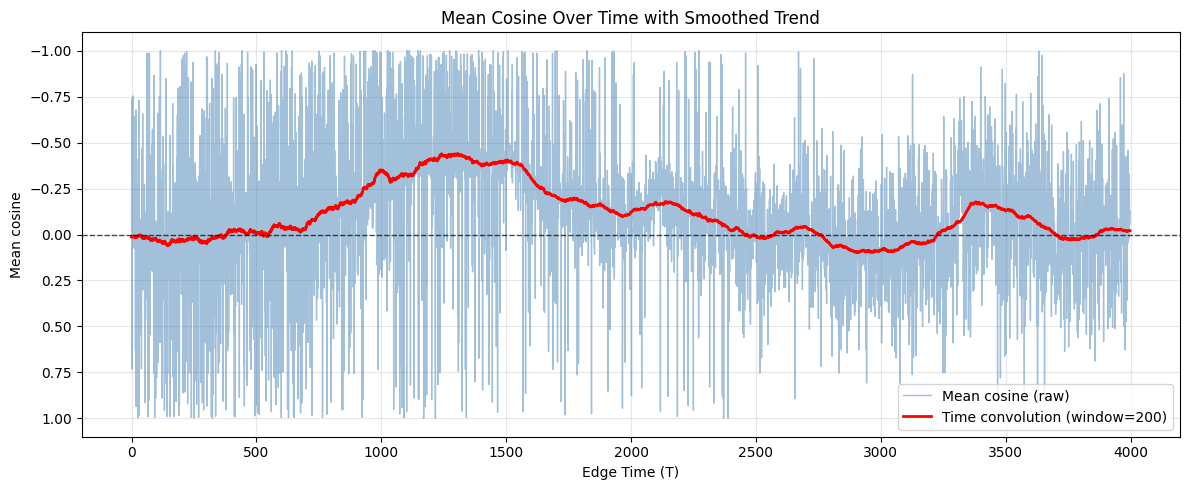

In [82]:
# Mean cosine over time with convolutional smoothing (window=90)

if 'EDGE_TIME' in merged.columns:
    time_vals = merged['EDGE_TIME']
    time_label = 'Edge Time (T)'
else:
    time_vals = (merged['POSITION_T_source'] + merged['POSITION_T_target']) / 2
    time_label = 'Time (T) - Midpoint'

plot_df = pd.DataFrame({'time': time_vals, 'cosine': merged['cosine']}).dropna()
mean_cos_over_time = (
    plot_df
    .groupby('time', as_index=False)['cosine']
    .mean()
    .sort_values('time')
)

# Time convolution smoothing using a flat kernel of length 90
window = 200
kernel = np.ones(window) / window
smoothed = np.convolve(mean_cos_over_time['cosine'].values, kernel, mode='same')

plt.figure(figsize=(12, 5))
plt.plot(
    mean_cos_over_time['time'],
    mean_cos_over_time['cosine'],
    color='steelblue',
    linewidth=1,
    alpha=0.5,
    label='Mean cosine (raw)'
)
plt.plot(
    mean_cos_over_time['time'],
    smoothed,
    color='red',
    linewidth=2,
    label='Time convolution (window=200)'
)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel(time_label)
plt.ylabel('Mean cosine')
plt.title('Mean Cosine Over Time with Smoothed Trend')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

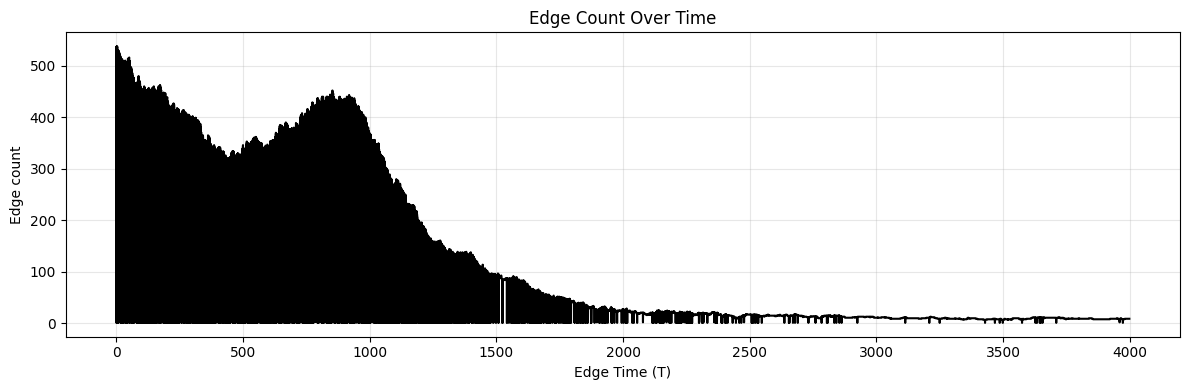

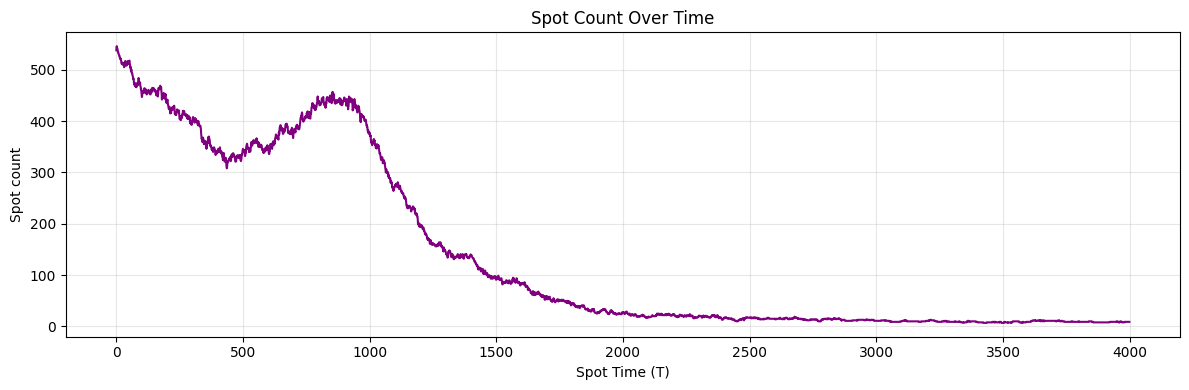

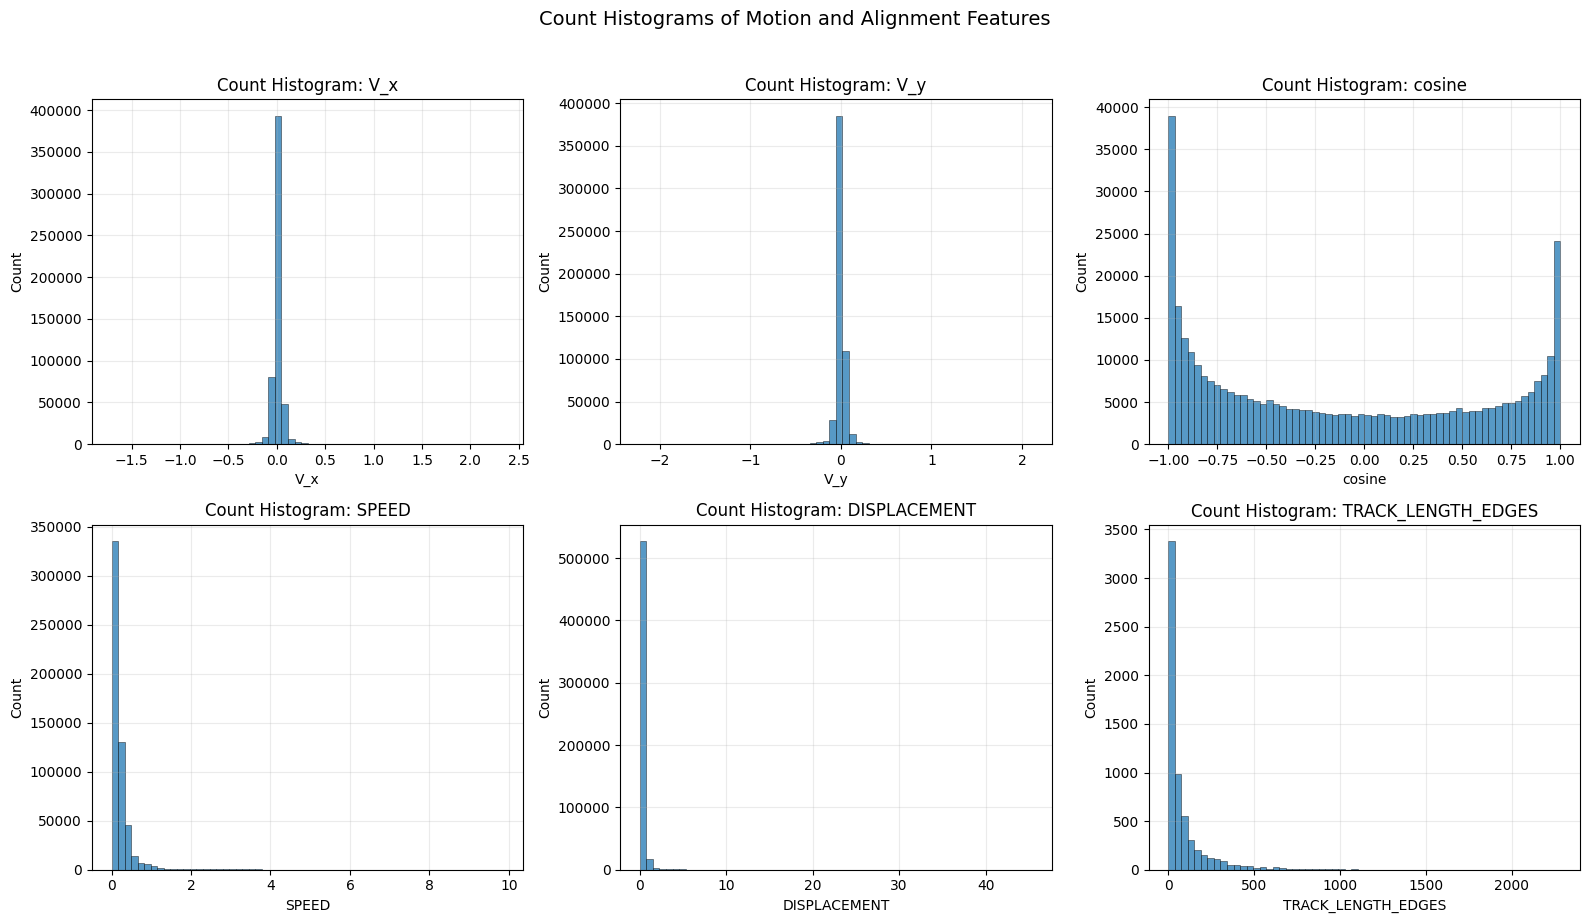

In [13]:
# Count vs time + count histograms for key motion/alignment features

if 'EDGE_TIME' in merged.columns:
    time_vals = merged['EDGE_TIME']
    time_label = 'Edge Time (T)'
else:
    time_vals = (merged['POSITION_T_source'] + merged['POSITION_T_target']) / 2
    time_label = 'Time (T) - Midpoint'

plot_df = merged.copy()
plot_df['__time__'] = time_vals

# 1) Edge count vs time
edge_count_over_time = (
    plot_df[['__time__']]
    .dropna()
    .groupby('__time__', as_index=False)
    .size()
    .sort_values('__time__')
)

plt.figure(figsize=(12, 4))
plt.plot(edge_count_over_time['__time__'], edge_count_over_time['size'], color='black', linewidth=1.5)
plt.xlabel(time_label)
plt.ylabel('Edge count')
plt.title('Edge Count Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Spot count vs time
if 'spots' in globals() and 'POSITION_T' in spots.columns:
    spot_count_over_time = (
        spots[['POSITION_T']]
        .dropna()
        .groupby('POSITION_T', as_index=False)
        .size()
        .sort_values('POSITION_T')
    )
    spot_time_col = 'POSITION_T'
else:
    # Fallback from merged table if spots DataFrame is unavailable
    spot_count_over_time = (
        pd.concat(
            [
                plot_df[['SPOT_SOURCE_ID', 'POSITION_T_source']].rename(
                    columns={'SPOT_SOURCE_ID': 'SPOT_ID', 'POSITION_T_source': 'POSITION_T'}
                ),
                plot_df[['SPOT_TARGET_ID', 'POSITION_T_target']].rename(
                    columns={'SPOT_TARGET_ID': 'SPOT_ID', 'POSITION_T_target': 'POSITION_T'}
                ),
            ],
            axis=0,
            ignore_index=True,
        )
        .dropna(subset=['SPOT_ID', 'POSITION_T'])
        .drop_duplicates(subset=['SPOT_ID', 'POSITION_T'])
        .groupby('POSITION_T', as_index=False)
        .size()
        .sort_values('POSITION_T')
    )
    spot_time_col = 'POSITION_T'

plt.figure(figsize=(12, 4))
plt.plot(spot_count_over_time[spot_time_col], spot_count_over_time['size'], color='purple', linewidth=1.5)
plt.xlabel('Spot Time (T)')
plt.ylabel('Spot count')
plt.title('Spot Count Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Count histograms
track_length_series = plot_df.groupby('TRACK_ID').size().rename('TRACK_LENGTH_EDGES')

hist_specs = [
    ('V_x', 'V_x'),
    ('V_y', 'V_y'),
    ('cosine', 'cosine'),
    ('SPEED', 'SPEED'),
    ('DISPLACEMENT', 'DISPLACEMENT'),
    ('TRACK_LENGTH_EDGES', track_length_series),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (label, source) in zip(axes, hist_specs):
    if isinstance(source, str):
        if source in plot_df.columns:
            vals = pd.to_numeric(plot_df[source], errors='coerce').dropna()
        else:
            vals = pd.Series(dtype=float)
    else:
        vals = pd.to_numeric(source, errors='coerce').dropna()

    if len(vals) > 0:
        ax.hist(vals, bins=60, alpha=0.75, edgecolor='black', linewidth=0.4)
        ax.set_title(f'Count Histogram: {label}')
    else:
        ax.text(0.5, 0.5, f'{label} not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Count Histogram: {label}')

    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.grid(alpha=0.25)

plt.suptitle('Count Histograms of Motion and Alignment Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Exploratory Data Analysis

## Cosine Analysis

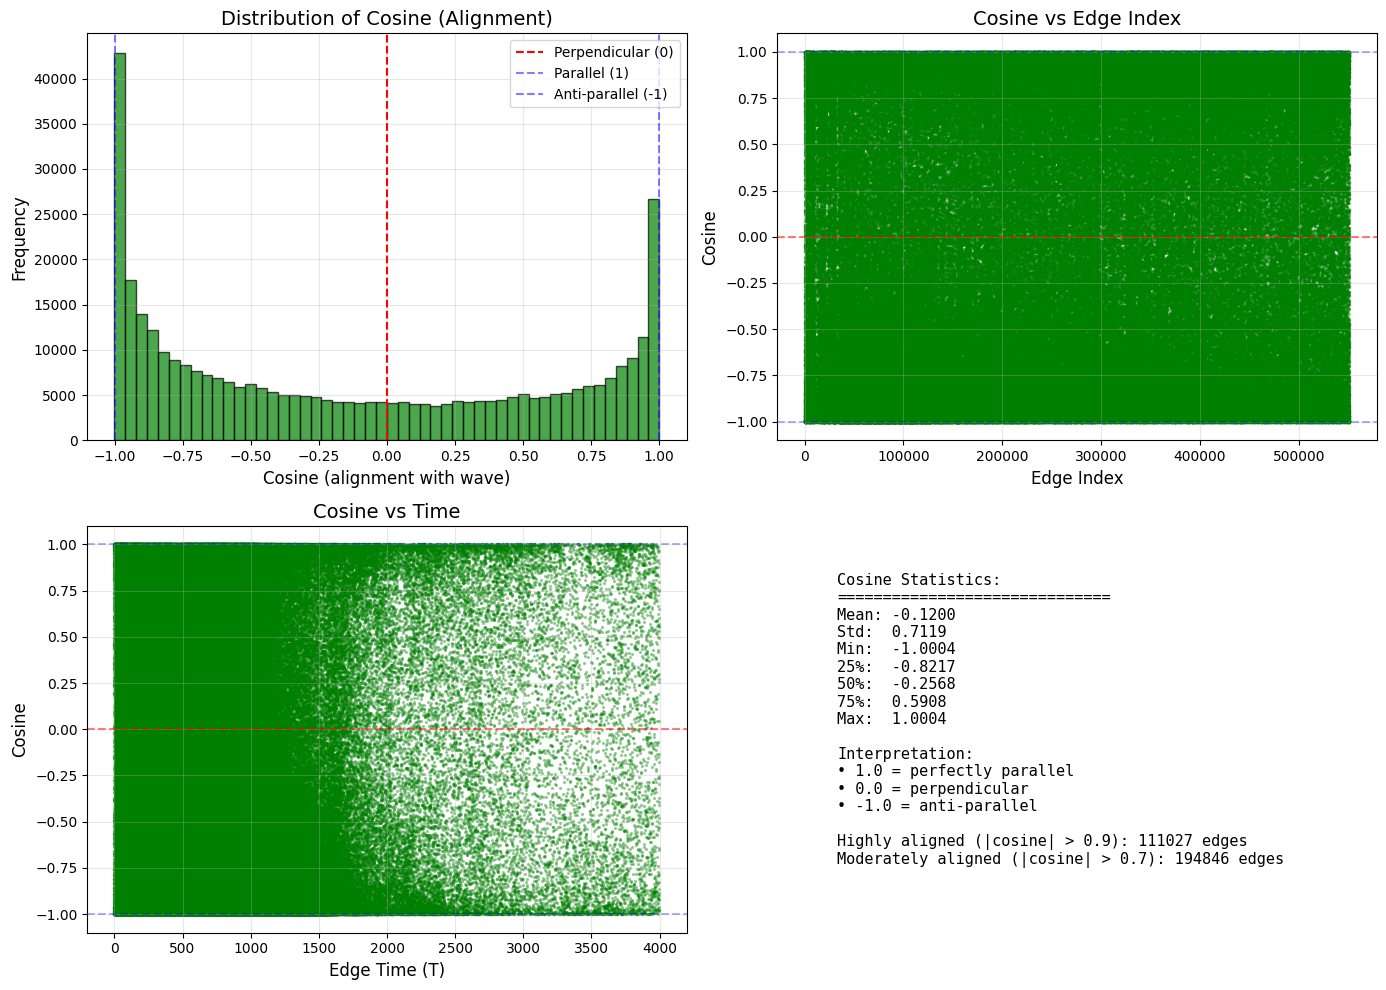

In [14]:
# Visualize cosine (alignment with wave direction)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of cosine values
axes[0, 0].hist(merged['cosine'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 0].set_xlabel('Cosine (alignment with wave)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Cosine (Alignment)', fontsize=14)
axes[0, 0].axvline(0, color='red', linestyle='--', label='Perpendicular (0)')
axes[0, 0].axvline(1, color='blue', linestyle='--', alpha=0.5, label='Parallel (1)')
axes[0, 0].axvline(-1, color='blue', linestyle='--', alpha=0.5, label='Anti-parallel (-1)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Cosine vs Edge Index
axes[0, 1].scatter(merged.index, merged['cosine'], alpha=0.3, s=2, color='green')
axes[0, 1].set_xlabel('Edge Index', fontsize=12)
axes[0, 1].set_ylabel('Cosine', fontsize=12)
axes[0, 1].set_title('Cosine vs Edge Index', fontsize=14)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].axhline(1, color='blue', linestyle='--', alpha=0.3)
axes[0, 1].axhline(-1, color='blue', linestyle='--', alpha=0.3)
axes[0, 1].grid(True, alpha=0.3)

# Cosine vs Time
if 'EDGE_TIME' in merged.columns:
    T = merged['EDGE_TIME']
    time_label = 'Edge Time (T)'
else:
    T = (merged['POSITION_T_source'] + merged['POSITION_T_target']) / 2
    time_label = 'Time (T) - Midpoint'

axes[1, 0].scatter(T, merged['cosine'], alpha=0.3, s=2, color='green')
axes[1, 0].set_xlabel(time_label, fontsize=12)
axes[1, 0].set_ylabel('Cosine', fontsize=12)
axes[1, 0].set_title('Cosine vs Time', fontsize=14)
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axhline(1, color='blue', linestyle='--', alpha=0.3)
axes[1, 0].axhline(-1, color='blue', linestyle='--', alpha=0.3)
axes[1, 0].grid(True, alpha=0.3)

# Statistics summary
cosine_stats = merged['cosine'].describe()
axes[1, 1].axis('off')
stats_text = f"""Cosine Statistics:
{'='*30}
Mean: {cosine_stats['mean']:.4f}
Std:  {cosine_stats['std']:.4f}
Min:  {cosine_stats['min']:.4f}
25%:  {cosine_stats['25%']:.4f}
50%:  {cosine_stats['50%']:.4f}
75%:  {cosine_stats['75%']:.4f}
Max:  {cosine_stats['max']:.4f}

Interpretation:
• 1.0 = perfectly parallel
• 0.0 = perpendicular
• -1.0 = anti-parallel

Highly aligned (|cosine| > 0.9): {((merged['cosine'].abs() > 0.9).sum())} edges
Moderately aligned (|cosine| > 0.7): {((merged['cosine'].abs() > 0.7).sum())} edges
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
                verticalalignment='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

Since the wave propagates down and to the left, it would make sense for the **cosine of the instantaneous edge velocities** to be *more* negative, as it should move not with the wave but in the opposite direction of the wave, towards its origin (top right). Any amount of **anti-parallelism** is what we're looking for.

We should also use a technique for noise removal and sparsity handling.

## Parallelism and Orthogonality Analysis

In [15]:
# Parallel component (along wave direction)
merged['V_parallel'] = V_x * wave_x_unit + V_y * wave_y_unit

# Orthogonal component (projection/perpendicular to wave)
merged['V_orthogonal'] = V_x * (-wave_y_unit) + V_y * wave_x_unit  # rotate wave vector 90°

In [16]:
# Extract V_parallel and V_orthogonal as Series
V_parallel = merged['V_parallel']
V_orthogonal = merged['V_orthogonal']

print(f"V_parallel: {len(V_parallel)} values")
print(f"V_orthogonal: {len(V_orthogonal)} values")
print(f"\nV_parallel stats:")
print(V_parallel.describe())
print(f"\nV_orthogonal stats:")
print(V_orthogonal.describe())

V_parallel: 551198 values
V_orthogonal: 551198 values

V_parallel stats:
count    551198.000000
mean         -0.006182
std           0.073634
min          -2.404064
25%          -0.020715
50%           0.000000
75%           0.005067
max           1.972457
Name: V_parallel, dtype: float64

V_orthogonal stats:
count    551198.000000
mean          0.000667
std           0.073310
min          -2.147242
25%          -0.011230
50%           0.000000
75%           0.012880
max           1.913915
Name: V_orthogonal, dtype: float64


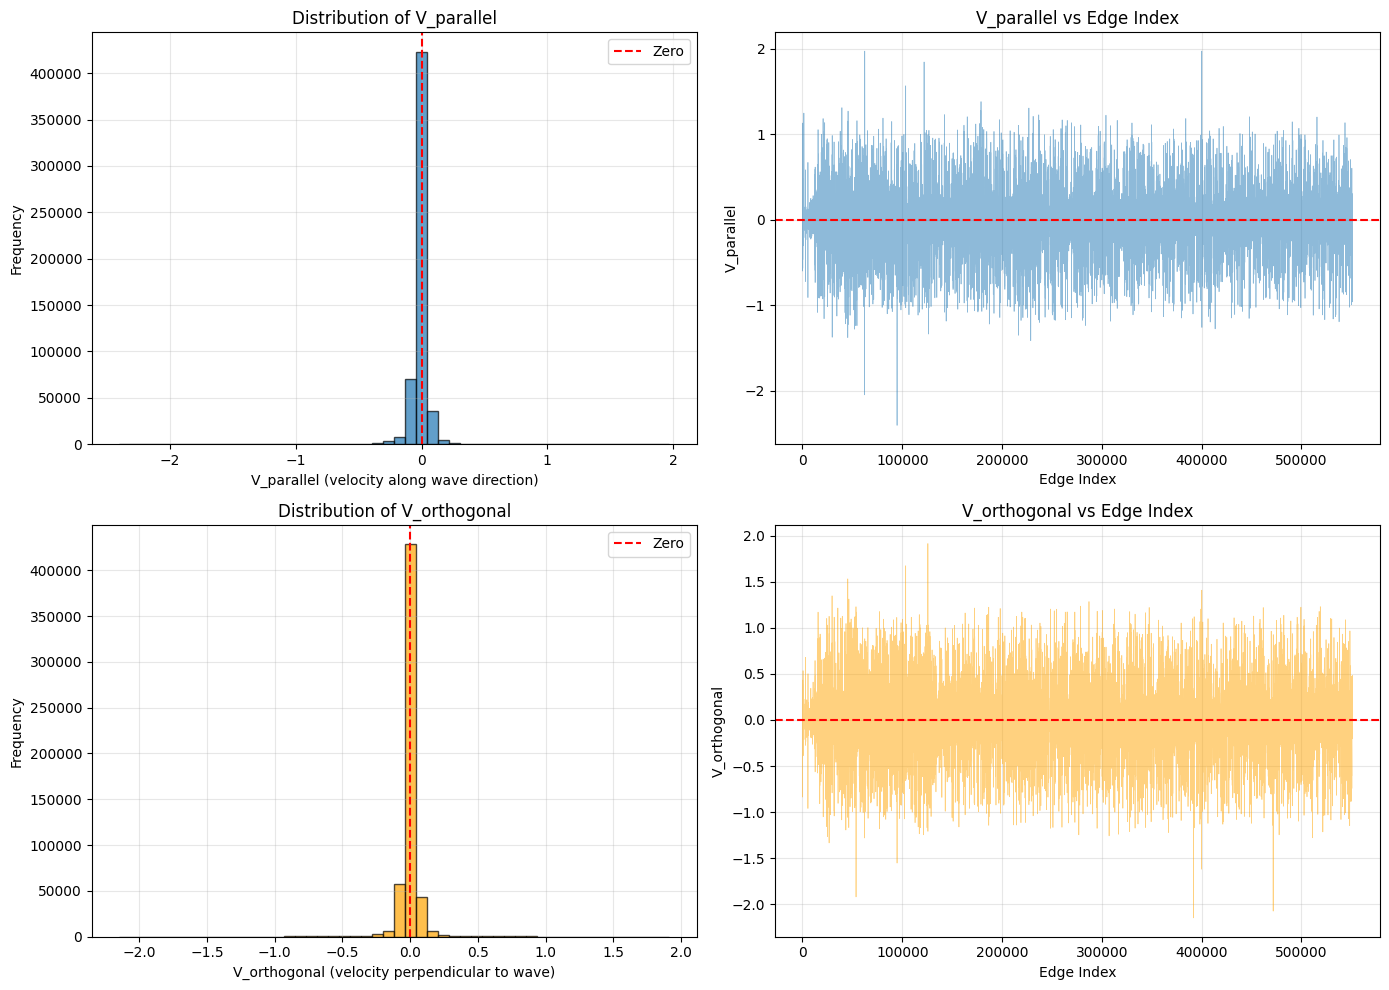

In [17]:
# Create plots for V_parallel and V_orthogonal
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# V_parallel plots
axes[0, 0].hist(V_parallel, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('V_parallel (velocity along wave direction)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of V_parallel')
axes[0, 0].axvline(0, color='red', linestyle='--', label='Zero')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(V_parallel.index, V_parallel.values, alpha=0.5, linewidth=0.5)
axes[0, 1].set_xlabel('Edge Index')
axes[0, 1].set_ylabel('V_parallel')
axes[0, 1].set_title('V_parallel vs Edge Index')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].grid(True, alpha=0.3)

# V_orthogonal plots
axes[1, 0].hist(V_orthogonal, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('V_orthogonal (velocity perpendicular to wave)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of V_orthogonal')
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(V_orthogonal.index, V_orthogonal.values, alpha=0.5, linewidth=0.5, color='orange')
axes[1, 1].set_xlabel('Edge Index')
axes[1, 1].set_ylabel('V_orthogonal')
axes[1, 1].set_title('V_orthogonal vs Edge Index')
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

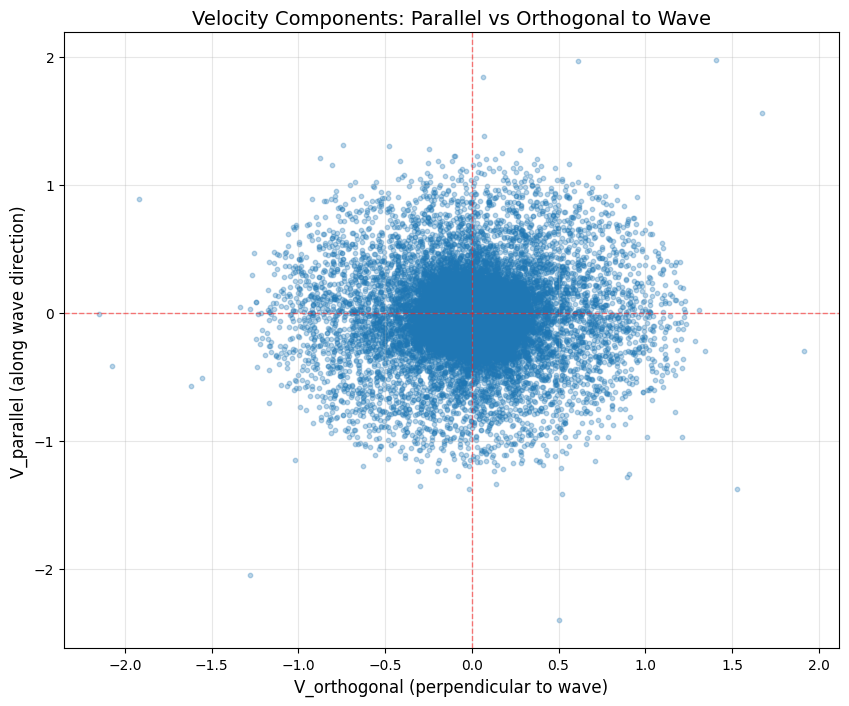

Quadrant Analysis:
Q1 (V_orthogonal > 0, V_parallel > 0): 79970 edges
Q2 (V_orthogonal < 0, V_parallel > 0): 75558 edges
Q3 (V_orthogonal < 0, V_parallel < 0): 104037 edges
Q4 (V_orthogonal > 0, V_parallel < 0): 106200 edges


In [18]:
# Scatter plot: V_parallel vs V_orthogonal
plt.figure(figsize=(10, 8))
plt.scatter(V_orthogonal, V_parallel, alpha=0.3, s=10)
plt.xlabel('V_orthogonal (perpendicular to wave)', fontsize=12)
plt.ylabel('V_parallel (along wave direction)', fontsize=12)
plt.title('Velocity Components: Parallel vs Orthogonal to Wave', fontsize=14)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# Print quadrant analysis
print("Quadrant Analysis:")
print(f"Q1 (V_orthogonal > 0, V_parallel > 0): {((V_orthogonal > 0) & (V_parallel > 0)).sum()} edges")
print(f"Q2 (V_orthogonal < 0, V_parallel > 0): {((V_orthogonal < 0) & (V_parallel > 0)).sum()} edges")
print(f"Q3 (V_orthogonal < 0, V_parallel < 0): {((V_orthogonal < 0) & (V_parallel < 0)).sum()} edges")
print(f"Q4 (V_orthogonal > 0, V_parallel < 0): {((V_orthogonal > 0) & (V_parallel < 0)).sum()} edges")

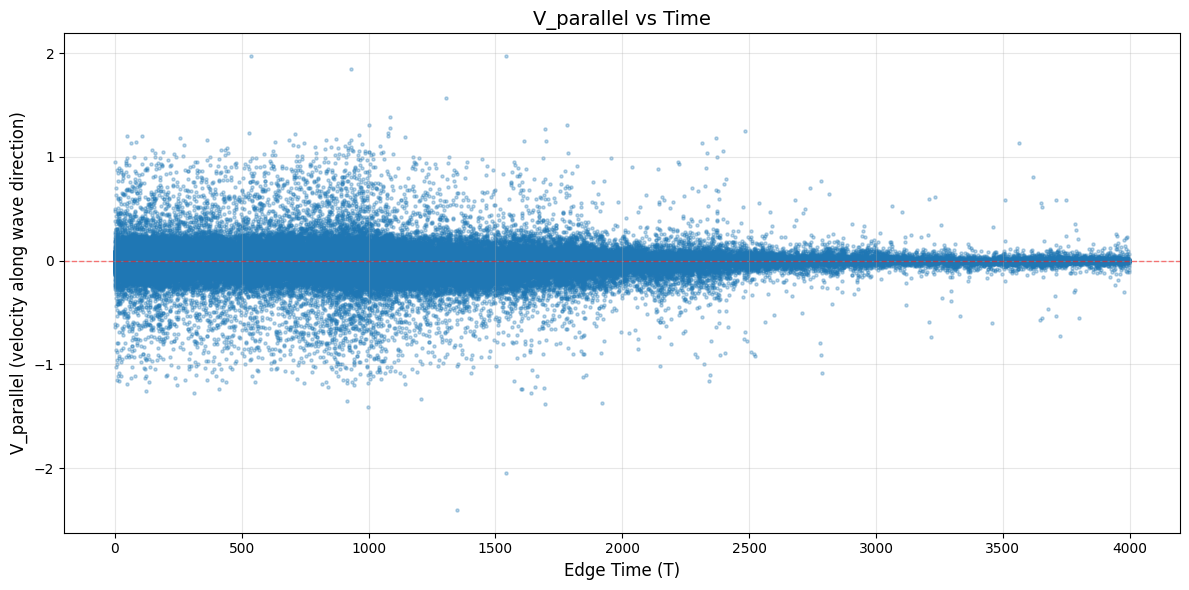

In [19]:
# Use EDGE_TIME if available, otherwise use average of source and target times
if 'EDGE_TIME' in merged.columns:
    T = merged['EDGE_TIME']
    time_label = 'Edge Time (T)'
else:
    # Use midpoint time between source and target
    T = (merged['POSITION_T_source'] + merged['POSITION_T_target']) / 2
    time_label = 'Time (T) - Midpoint'

# Plot V_parallel vs Time
plt.figure(figsize=(12, 6))
plt.scatter(T, V_parallel.values, alpha=0.3, s=5)
plt.xlabel(time_label, fontsize=12)
plt.ylabel('V_parallel (velocity along wave direction)', fontsize=12)
plt.title('V_parallel vs Time', fontsize=14)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Futher Cosine Analysis

For each track and time bin, compute the average cosine across its edges. We create a 2D array, such that heatmap **H[track_index, time_bin] = mean cosine**. We then show the heatmap to see when each track tends to align with the wave. Overall, blue is best.

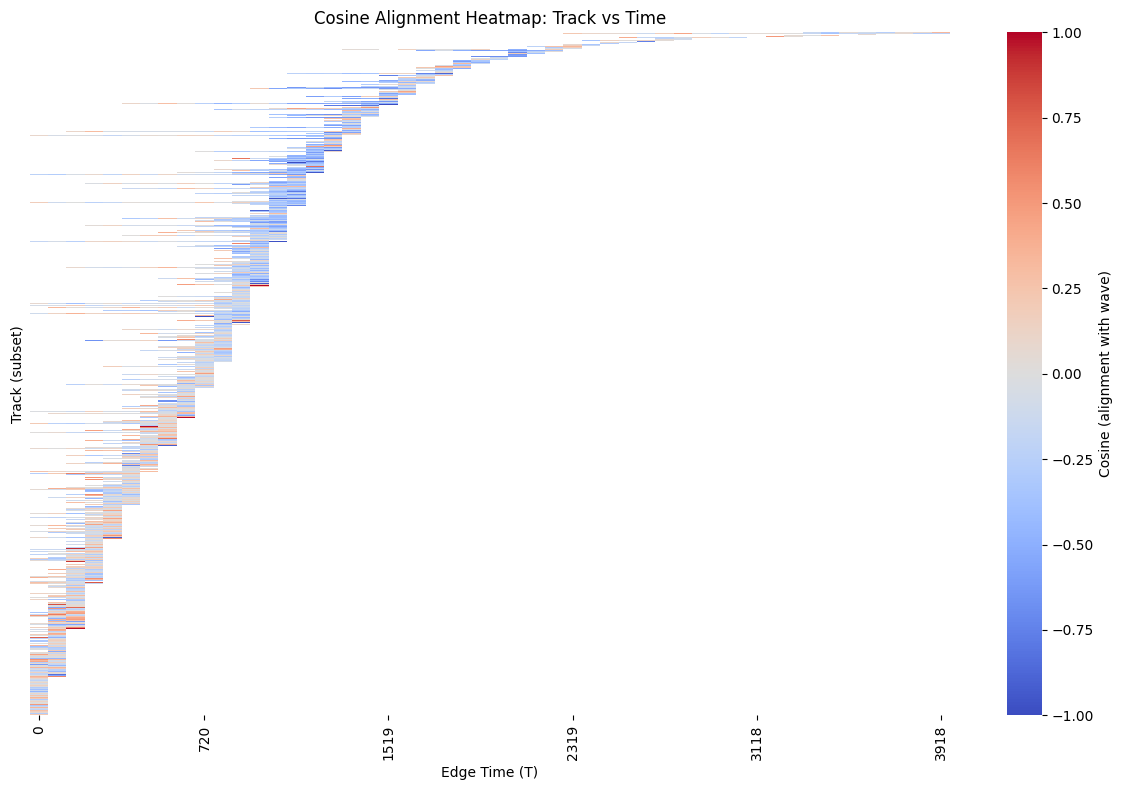

In [20]:
# Heatmap 1: Cosine vs Time vs Track ID

# Choose time axis
if 'EDGE_TIME' in merged.columns:
    time_vals = merged['EDGE_TIME']
    time_label = 'Edge Time (T)'
else:
    time_vals = (merged['POSITION_T_source'] + merged['POSITION_T_target']) / 2
    time_label = 'Time (T) - Midpoint'

# Bin time into, say, 50 bins
n_time_bins = 50
time_bins = np.linspace(time_vals.min(), time_vals.max(), n_time_bins + 1)
merged['time_bin'] = np.digitize(time_vals, time_bins) - 1

# Limit to tracks with enough edges to show structure
min_edges_per_track = 20
track_counts = merged['TRACK_ID'].value_counts()
valid_tracks = track_counts[track_counts >= min_edges_per_track].index

subset = merged[merged['TRACK_ID'].isin(valid_tracks)].copy()

# Map track IDs to consecutive row indices
track_id_to_row = {tid: i for i, tid in enumerate(sorted(valid_tracks))}
subset['track_row'] = subset['TRACK_ID'].map(track_id_to_row)

# Initialize heatmap array with NaNs
heat = np.full((len(valid_tracks), n_time_bins), np.nan)

# Fill with mean cosine per (track_row, time_bin)
for (row, tbin), group in subset.groupby(['track_row', 'time_bin']):
    if 0 <= tbin < n_time_bins:
        heat[row, tbin] = group['cosine'].mean()

plt.figure(figsize=(12, 8))
# Use a diverging colormap centered at 0
sns.heatmap(
    heat,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Cosine (alignment with wave)'}
)
plt.xlabel(time_label)
plt.ylabel('Track (subset)')
plt.title('Cosine Alignment Heatmap: Track vs Time')
# Approximate time tick labels
xticks = np.linspace(0, n_time_bins - 1, 6, dtype=int)
xtick_labels = [f"{time_bins[i]:.0f}" for i in xticks]
plt.xticks(xticks + 0.5, xtick_labels)
plt.yticks([])
plt.tight_layout()
plt.show()

We also bin time on one axis and cosine on the other, filling each cell with the count or density of edges in that (time, cosine) bin. This shows how the distribution of alignment evolves over time.

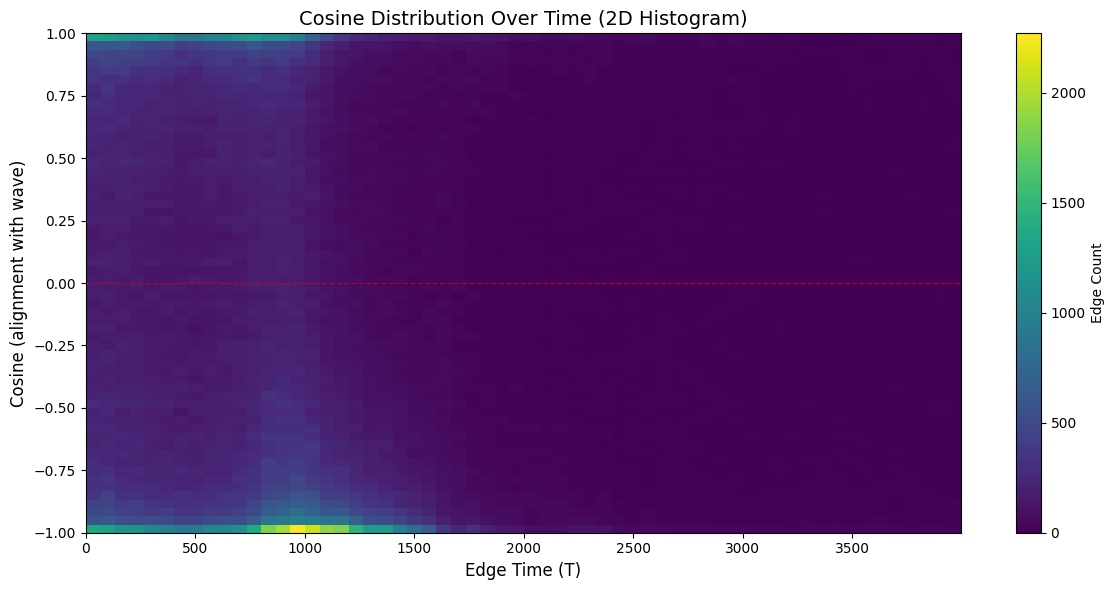

In [21]:
# Heatmap 2: Time vs Cosine distribution (2D histogram)

# Reuse time_vals from previous cell
if 'EDGE_TIME' in merged.columns:
    time_vals = merged['EDGE_TIME']
    time_label = 'Edge Time (T)'
else:
    time_vals = (merged['POSITION_T_source'] + merged['POSITION_T_target']) / 2
    time_label = 'Time (T) - Midpoint'

cos_vals = merged['cosine'].values

# Define bins
n_time_bins = 60
n_cos_bins = 60
time_bins = np.linspace(time_vals.min(), time_vals.max(), n_time_bins + 1)
cos_bins = np.linspace(-1, 1, n_cos_bins + 1)

# Compute 2D histogram: counts of edges in each (time, cosine) bin
H, xedges, yedges = np.histogram2d(time_vals, cos_vals, bins=[time_bins, cos_bins])

plt.figure(figsize=(12, 6))
# Transpose H so cosine is vertical axis
plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='viridis'
)
plt.colorbar(label='Edge Count')
plt.xlabel(time_label, fontsize=12)
plt.ylabel('Cosine (alignment with wave)', fontsize=12)
plt.title('Cosine Distribution Over Time (2D Histogram)', fontsize=14)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(1, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axhline(-1, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

### 3D Bimodal Distribution Density Visualizations


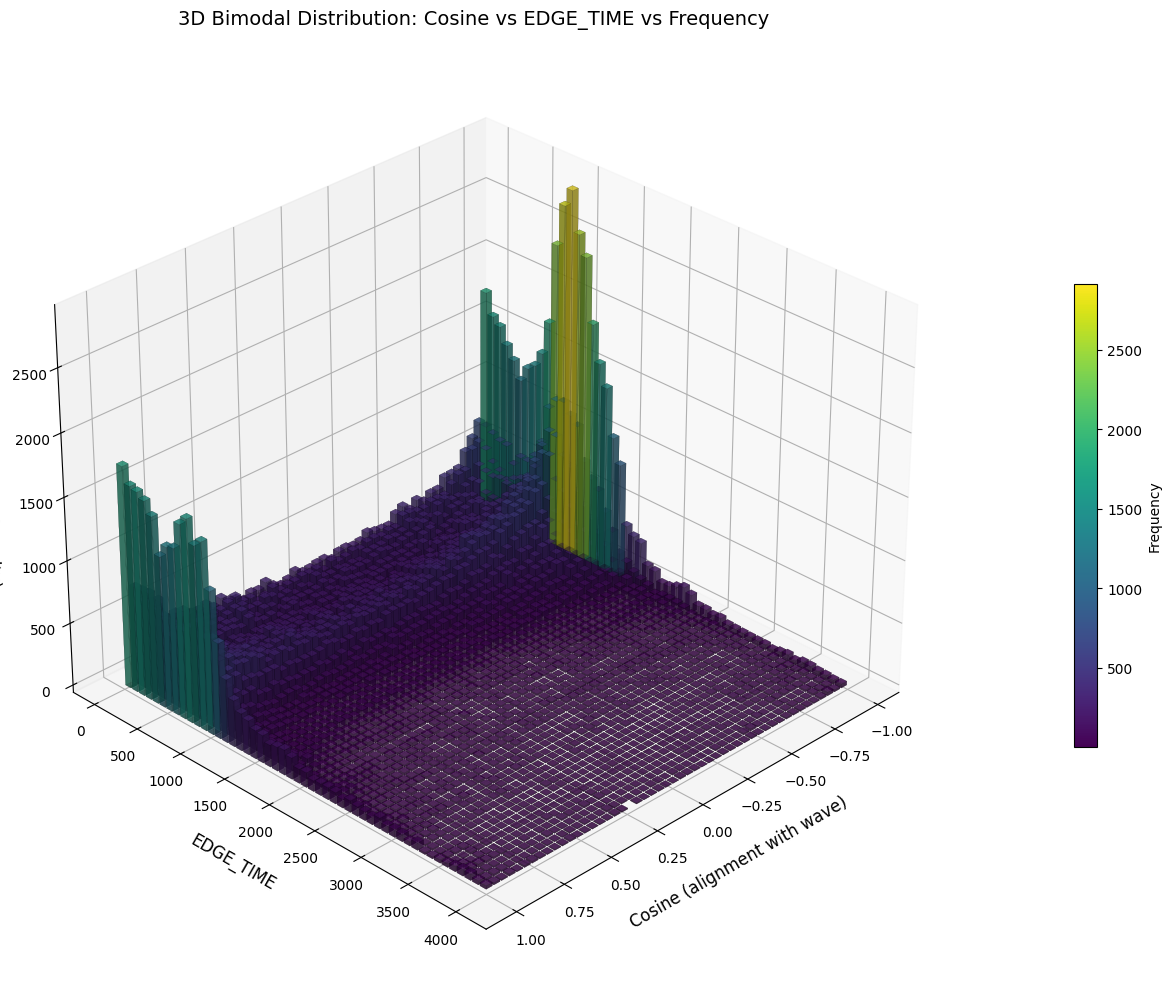


Statistics:
Total edges: 551198
Cosine range: [nan, nan]
EDGE_TIME range: [0.00, 3998.00]
Max frequency in bin: 2915.0
Bins with data: 2499 / 2500


In [22]:
# 3D Bimodal Distribution: Cosine vs Feature vs Frequency
from mpl_toolkits.mplot3d import Axes3D

# Choose feature to plot (EDGE_TIME, V_parallel, SPEED, etc.)
feature_name = 'EDGE_TIME'  # Change this to try different features
feature_data = merged[feature_name].values
cosine_data = merged['cosine'].values

# Create bins for histogram
n_cosine_bins = 50
n_feature_bins = 50

cosine_bins = np.linspace(-1, 1, n_cosine_bins + 1)
feature_bins = np.linspace(feature_data.min(), feature_data.max(), n_feature_bins + 1)

# Compute 2D histogram
H, cosine_edges, feature_edges = np.histogram2d(
    cosine_data, 
    feature_data, 
    bins=[cosine_bins, feature_bins]
)

# Get bin centers for plotting
cosine_centers = (cosine_edges[:-1] + cosine_edges[1:]) / 2
feature_centers = (feature_edges[:-1] + feature_edges[1:]) / 2

# Create meshgrid for 3D surface
Cosine_mesh, Feature_mesh = np.meshgrid(cosine_centers, feature_centers, indexing='ij')

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot as 3D bar chart (histogram bars)
# Only plot bars where frequency > 0 to reduce clutter
nonzero_mask = H > 0
x_pos = Cosine_mesh[nonzero_mask]
y_pos = Feature_mesh[nonzero_mask]
z_pos = np.zeros_like(x_pos)
dx = (cosine_edges[1] - cosine_edges[0]) * 0.8  # Bar width (80% of bin)
dy = (feature_edges[1] - feature_edges[0]) * 0.8
dz = H[nonzero_mask]

# Color bars by frequency (density)
colors = plt.cm.viridis(dz / dz.max())

# Create 3D bar plot
ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color=colors, alpha=0.6, edgecolor='black', linewidth=0.1)

ax.set_xlabel('Cosine (alignment with wave)', fontsize=12, labelpad=10)
ax.set_ylabel(f'{feature_name}', fontsize=12, labelpad=10)
ax.set_zlabel('Frequency (Density)', fontsize=12, labelpad=10)
ax.set_title(f'3D Bimodal Distribution: Cosine vs {feature_name} vs Frequency', fontsize=14, pad=20)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=dz.min(), vmax=dz.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, aspect=20, pad=0.1)
cbar.set_label('Frequency', fontsize=10)

# Set viewing angle
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nStatistics:")
print(f"Total edges: {len(merged)}")
print(f"Cosine range: [{cosine_data.min():.3f}, {cosine_data.max():.3f}]")
print(f"{feature_name} range: [{feature_data.min():.2f}, {feature_data.max():.2f}]")
print(f"Max frequency in bin: {H.max()}")
print(f"Bins with data: {np.sum(H > 0)} / {H.size}")

In [23]:
# Helper function to create 3D distribution plots for any feature combination
from utils import plot_3d_distribution
print("Helper function 'plot_3d_distribution' created!")
print("\nUsage:")
print("  plot_3d_distribution('feature1', 'feature2', merged)  # Shows both bar and surface")
print("  plot_3d_distribution('feature1', 'feature2', merged, plot_type='bar')  # Bar chart only")
print("  plot_3d_distribution('feature1', 'feature2', merged, plot_type='surface')  # Surface only")

Helper function 'plot_3d_distribution' created!

Usage:
  plot_3d_distribution('feature1', 'feature2', merged)  # Shows both bar and surface
  plot_3d_distribution('feature1', 'feature2', merged, plot_type='bar')  # Bar chart only
  plot_3d_distribution('feature1', 'feature2', merged, plot_type='surface')  # Surface only


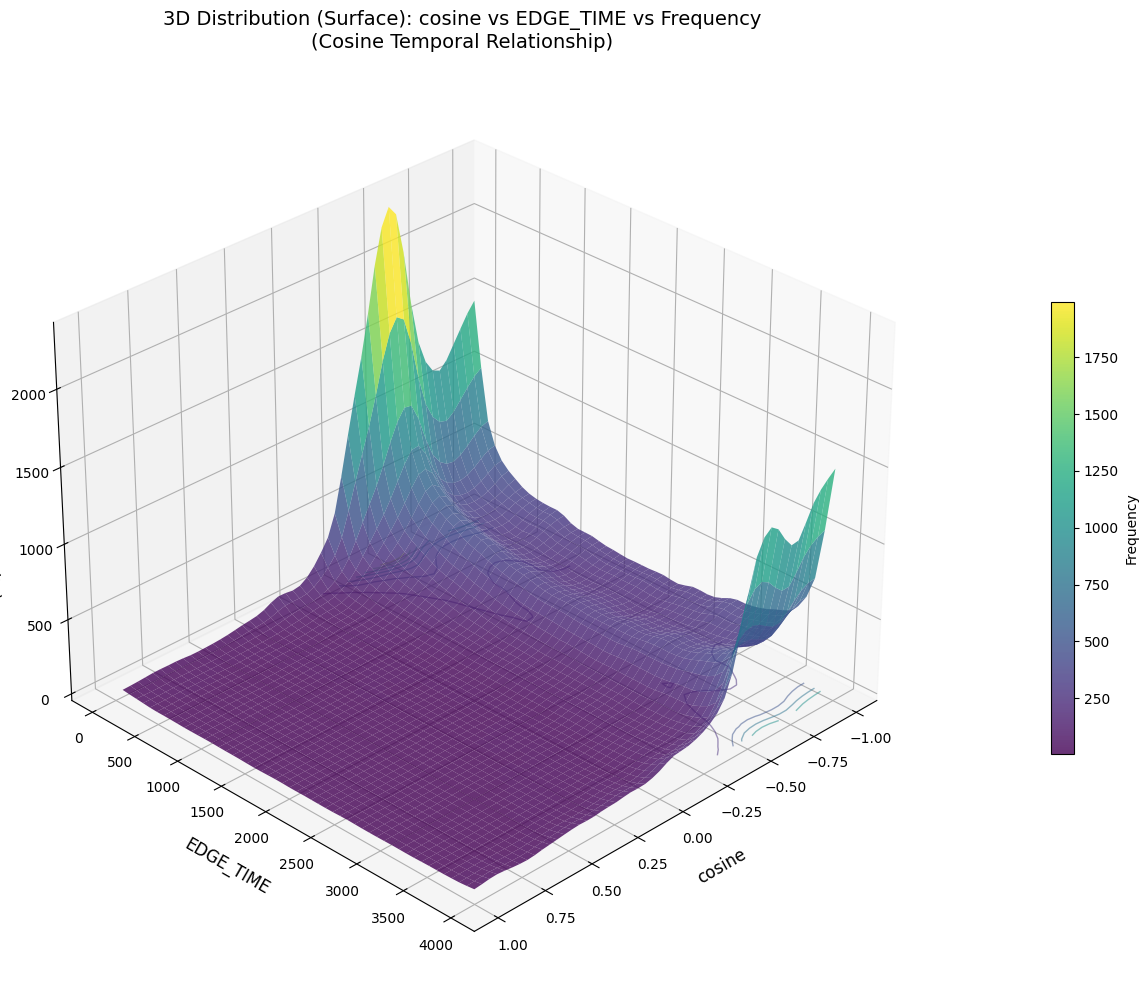


Statistics for cosine vs EDGE_TIME:
Total data points: 551198
Finite paired points used: 365765
cosine range: [-1.000, 1.000]
EDGE_TIME range: [0.000, 3998.000]
Max frequency in bin: 3218.0
Bins with data: 2499 / 2500


In [24]:
plot_3d_distribution('cosine', 'EDGE_TIME', merged, 
                     n_bins1=50, n_bins2=50, plot_type='surface',
                     title_suffix="\n(Cosine Temporal Relationship)")

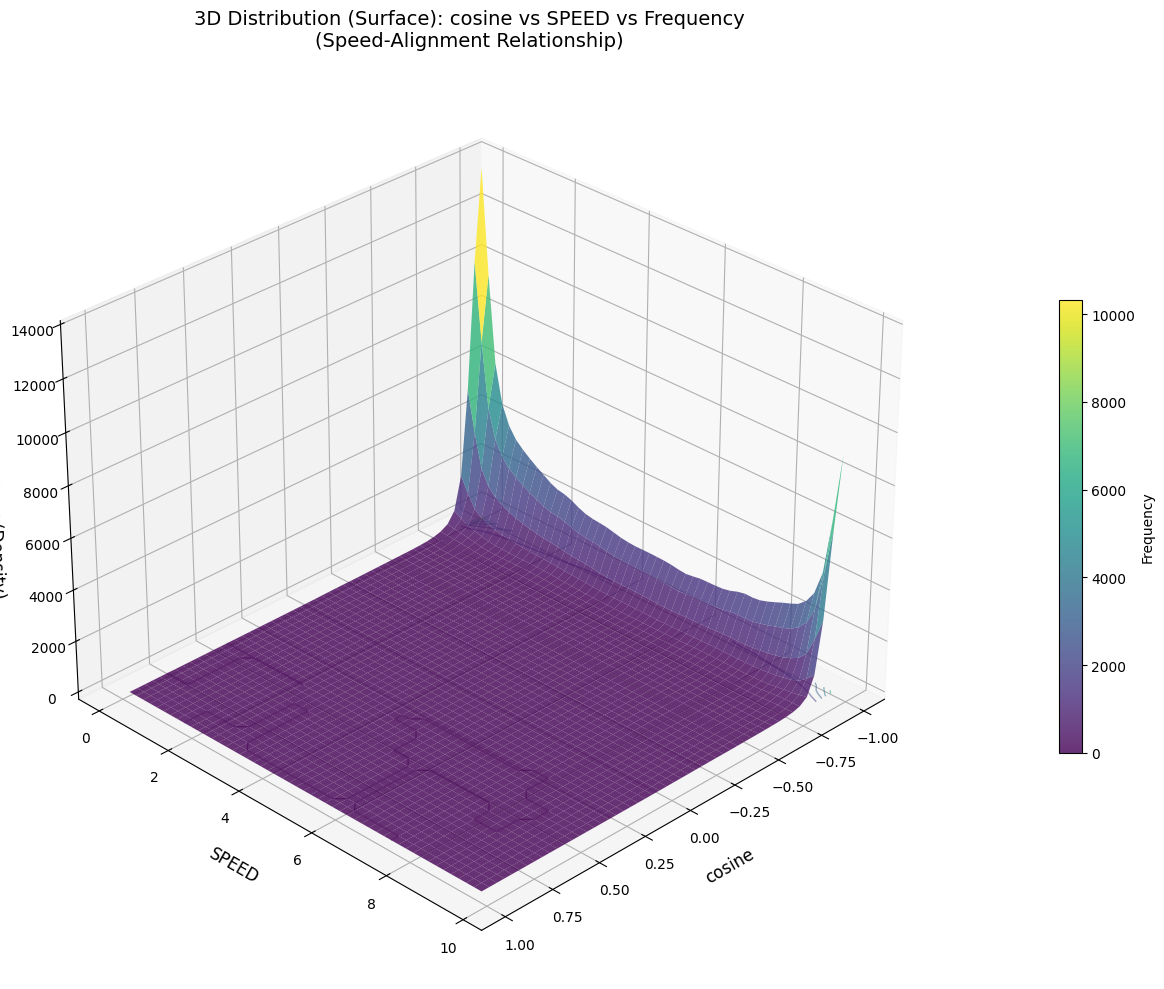


Statistics for cosine vs SPEED:
Total data points: 551198
Finite paired points used: 365765
cosine range: [-1.000, 1.000]
SPEED range: [0.000, 9.868]
Max frequency in bin: 20195.0
Bins with data: 1302 / 2500


In [25]:
# Shows if faster cells align better with the wave
plot_3d_distribution('cosine', 'SPEED', merged, 
                     n_bins1=50, n_bins2=50, plot_type='surface',
                     title_suffix="\n(Speed-Alignment Relationship)")

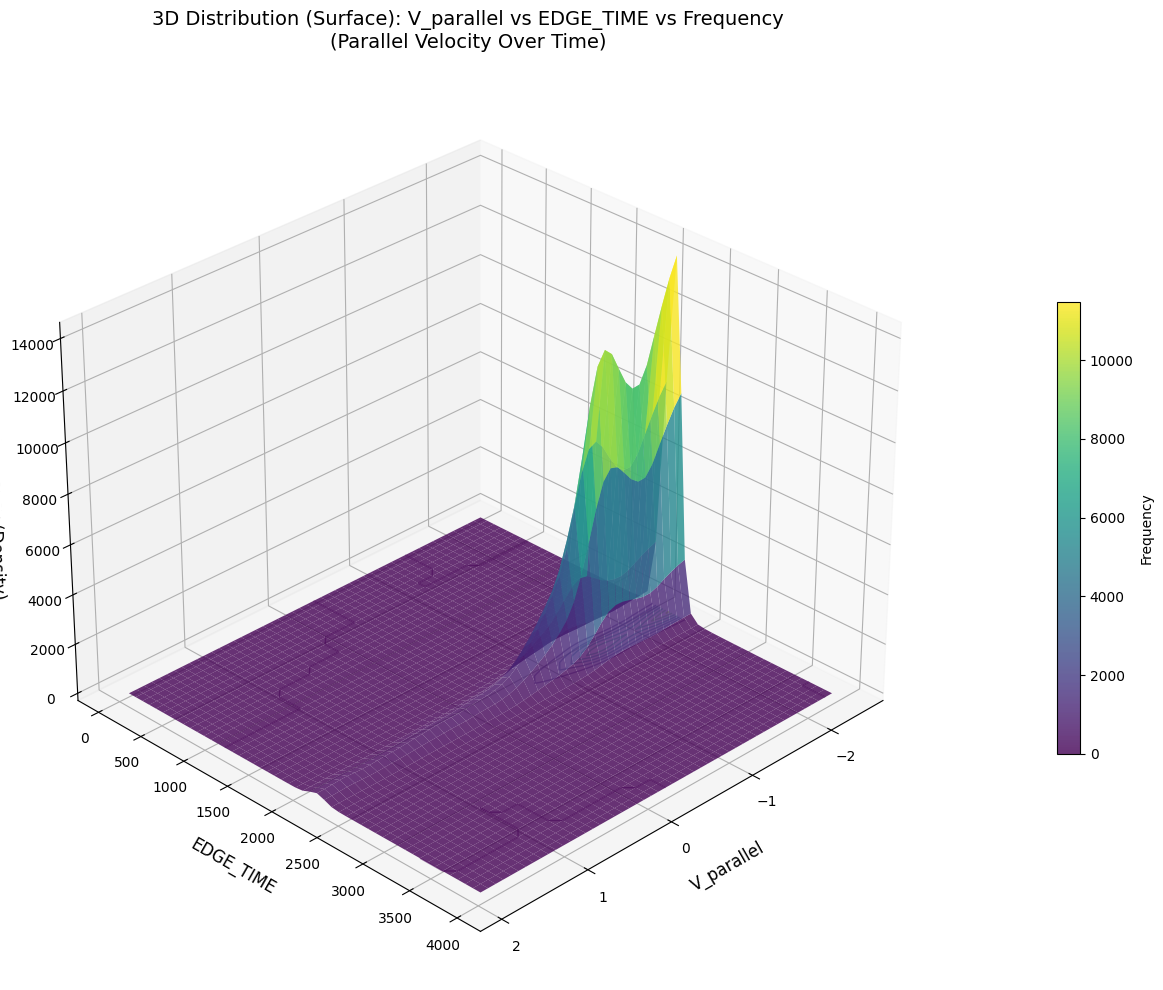


Statistics for V_parallel vs EDGE_TIME:
Total data points: 551198
Finite paired points used: 551198
V_parallel range: [-2.404, 1.972]
EDGE_TIME range: [0.000, 3998.000]
Max frequency in bin: 34110.0
Bins with data: 915 / 2500


In [26]:
# Shows how parallel velocity changes over time
plot_3d_distribution('V_parallel', 'EDGE_TIME', merged, 
                     n_bins1=50, n_bins2=50, plot_type='surface',
                     title_suffix="\n(Parallel Velocity Over Time)")

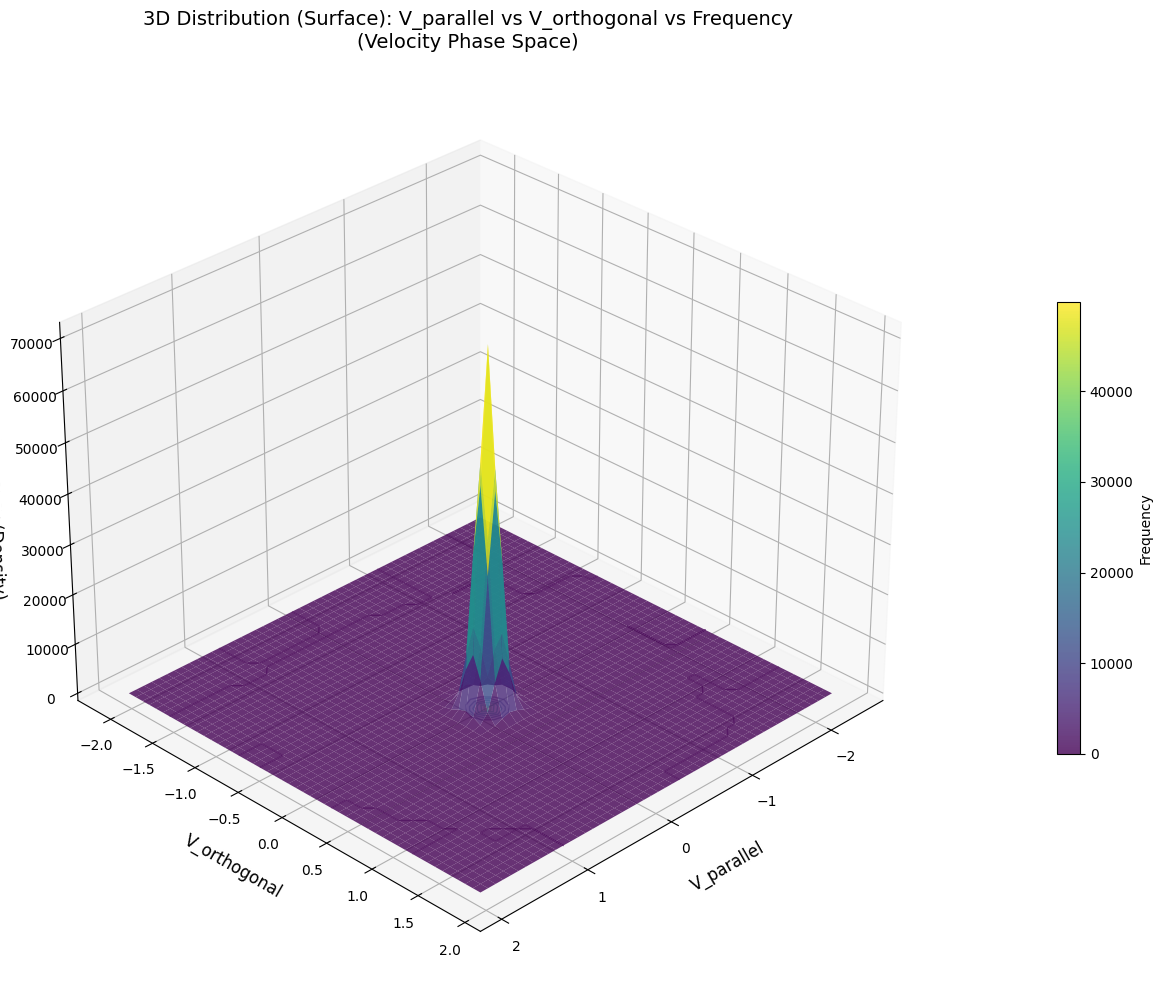


Statistics for V_parallel vs V_orthogonal:
Total data points: 551198
Finite paired points used: 551198
V_parallel range: [-2.404, 1.972]
V_orthogonal range: [-2.147, 1.914]
Max frequency in bin: 361121.0
Bins with data: 743 / 2500


In [27]:
# Shows velocity phase space - how do cells move in parallel vs perpendicular?
plot_3d_distribution('V_parallel', 'V_orthogonal', merged, 
                     n_bins1=50, n_bins2=50, plot_type='surface',
                     title_suffix="\n(Velocity Phase Space)")

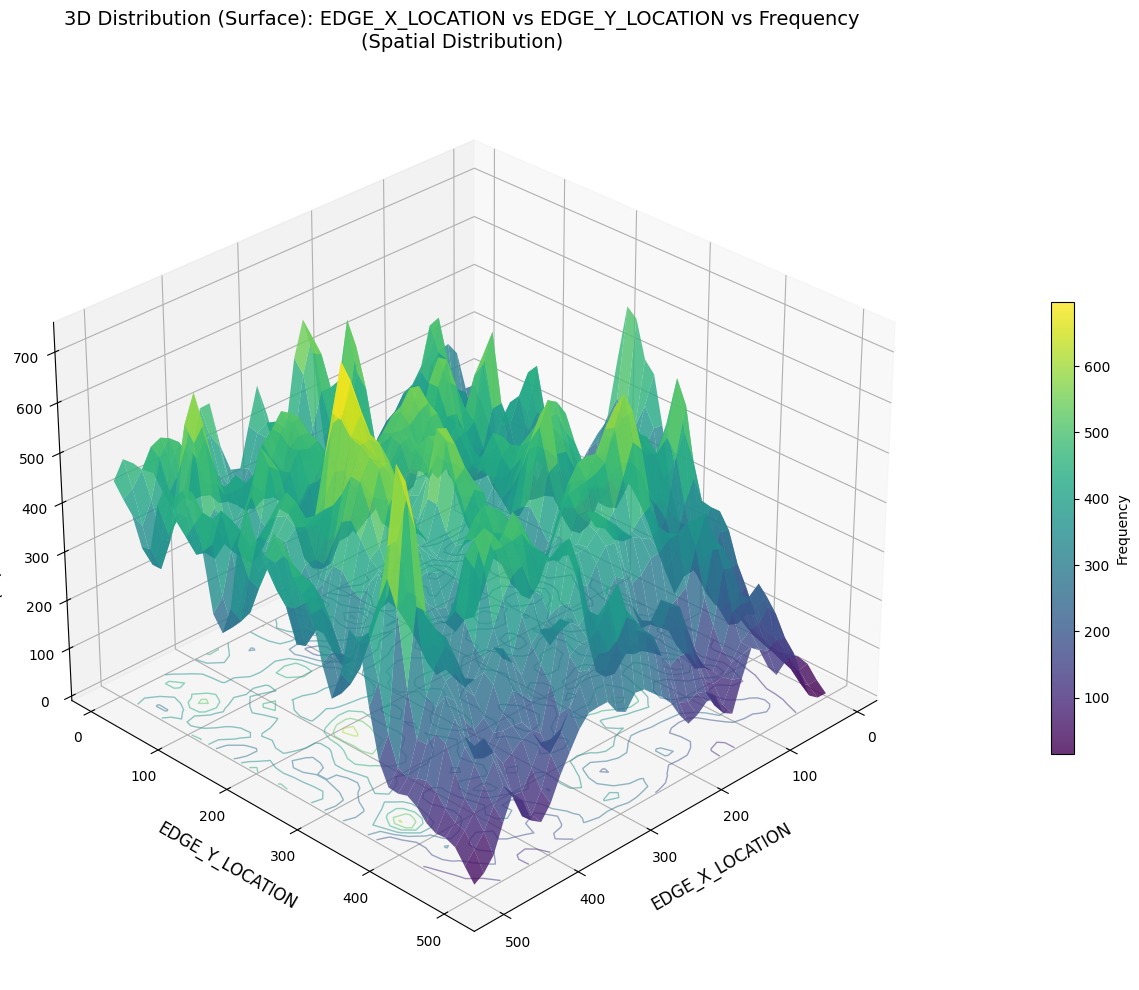


Statistics for EDGE_X_LOCATION vs EDGE_Y_LOCATION:
Total data points: 551198
Finite paired points used: 551198
EDGE_X_LOCATION range: [0.126, 509.075]
EDGE_Y_LOCATION range: [0.705, 510.004]
Max frequency in bin: 2078.0
Bins with data: 1576 / 1600


In [28]:
# Shows overall spatial distribution of cells
plot_3d_distribution('EDGE_X_LOCATION', 'EDGE_Y_LOCATION', merged, 
                     n_bins1=40, n_bins2=40, plot_type='surface',
                     title_suffix="\n(Spatial Distribution)")

In [81]:
from utils import plot_interactive_3d_surface

plot_interactive_3d_surface(merged)

Plotly renderer: notebook_connected


Time range: 0.0 to 3998.0
Cosine range: nan to nan
Max bin count: 2270.0 edges


In [30]:
# from utils import save_gif

# save_gif('cosine_vs_time_surface')

## Per-Track Mean-Velocity Cosine (Noise Removal)
- We group by the track ID and compute the average velocity components of the entire track, then take the dot product of that velocity to get the cosine of the average track velocity components and wave unit direction.
- This is an alternative to computing a cosine per instantaneous edge velocity and averaging the cosines, which is less accurate due to the noisiness of averaging cosines (more stochastic per row).
- Best interpreted as the *general track velocity direction with respect to the wave*.

Tracks with mean-velocity cosine < -0.7: 2354


/var/folders/ry/vzt_t9_x03b06vnwjq6nlns00000gn/T/ipykernel_7611/1433777717.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


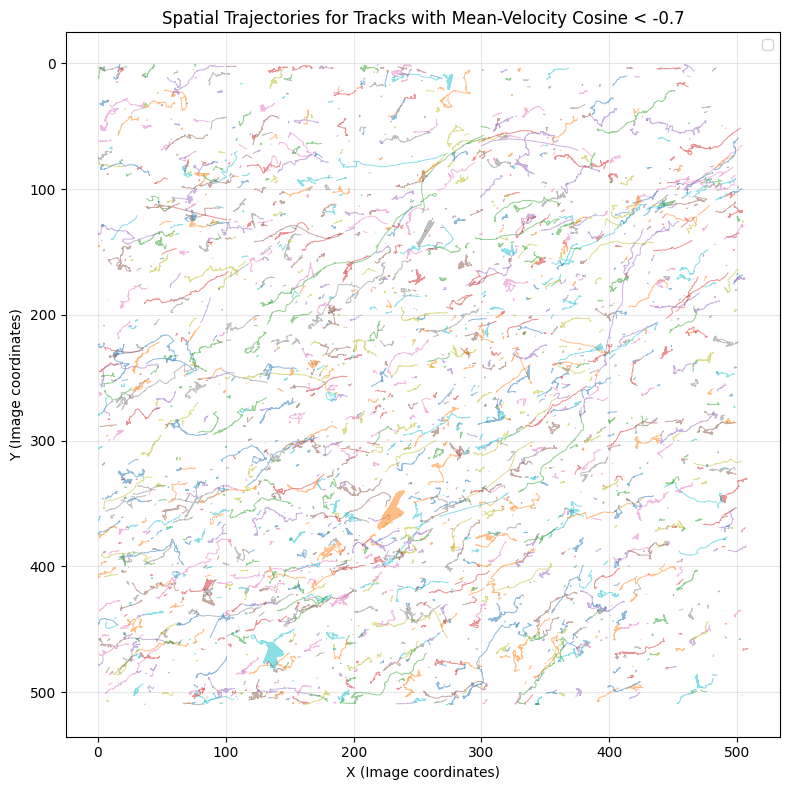

In [31]:
# Spatial plot of tracks whose *mean velocity vector* has cosine < 0.6 w.r.t. wave

# 1. Compute mean V_x, V_y per track
track_mean_vel = merged.groupby('TRACK_ID')[['V_x', 'V_y']].mean().copy()

# 2. Cosine of mean velocity vector with wave direction
# wave_x_unit, wave_y_unit are defined earlier in the notebook
track_mean_vel['speed_mean'] = np.sqrt(track_mean_vel['V_x']**2 + track_mean_vel['V_y']**2)
nonzero_mask = track_mean_vel['speed_mean'] > 0

# Initialize with NaNs to avoid divide-by-zero warnings
track_mean_vel['cos_mean_velocity'] = np.nan
track_mean_vel.loc[nonzero_mask, 'cos_mean_velocity'] = (
    track_mean_vel.loc[nonzero_mask, 'V_x'] * wave_x_unit +
    track_mean_vel.loc[nonzero_mask, 'V_y'] * wave_y_unit
) / track_mean_vel.loc[nonzero_mask, 'speed_mean']

# 3. Select tracks whose mean-velocity cosine is below threshold
threshold = -0.7
low_alignment_ids = track_mean_vel[track_mean_vel['cos_mean_velocity'] < threshold].index
print(f"Tracks with mean-velocity cosine < {threshold}: {len(low_alignment_ids)}")

# 4. Filter merged to only those tracks
low_alignment = merged[merged['TRACK_ID'].isin(low_alignment_ids)].copy()

# 5. Sort by track and time for cleaner trajectories
if 'EDGE_TIME' in low_alignment.columns:
    low_alignment = low_alignment.sort_values(['TRACK_ID', 'EDGE_TIME'])
else:
    low_alignment = low_alignment.sort_values(['TRACK_ID', 'POSITION_T_source'])

# 6. Spatial plot (image coordinates). Each track is one trajectory in x–y
plt.figure(figsize=(8, 8))

for tid, group in low_alignment.groupby('TRACK_ID'):
    plt.plot(
        group['EDGE_X_LOCATION'],
        group['EDGE_Y_LOCATION'],
        linewidth=0.7,
        alpha=0.5,
    )

# Optionally mark the final main centroid if defined
try:
    plt.scatter(centroid_x, centroid_y, c='red', s=80, marker='x', label='Final centroid')
except NameError:
    pass

plt.gca().invert_yaxis()  # keep ImageJ-style coordinates (origin at top-left)
plt.xlabel('X (Image coordinates)')
plt.ylabel('Y (Image coordinates)')
plt.title(f'Spatial Trajectories for Tracks with Mean-Velocity Cosine < {threshold}')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

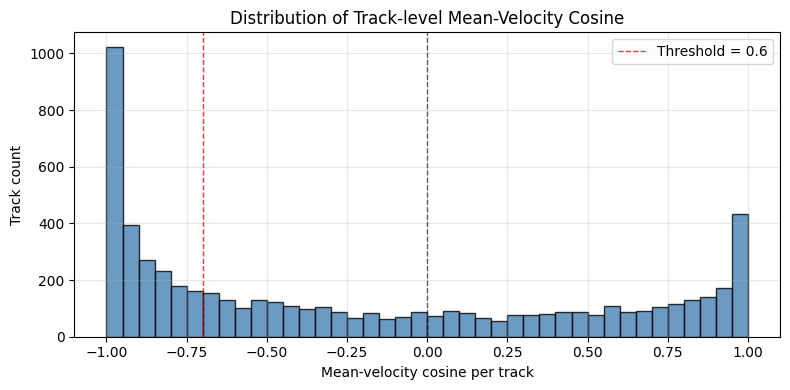

In [32]:
# Histogram of mean-velocity cosine per track
cos_vals_track = track_mean_vel['cos_mean_velocity'].dropna()

plt.figure(figsize=(8, 4))
plt.hist(cos_vals_track, bins=40, range=(-1, 1), color='steelblue', alpha=0.8, edgecolor='black')
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.axvline(threshold, color='red', linestyle='--', linewidth=1, alpha=0.8, label='Threshold = 0.6')
plt.xlabel('Mean-velocity cosine per track')
plt.ylabel('Track count')
plt.title('Distribution of Track-level Mean-Velocity Cosine')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

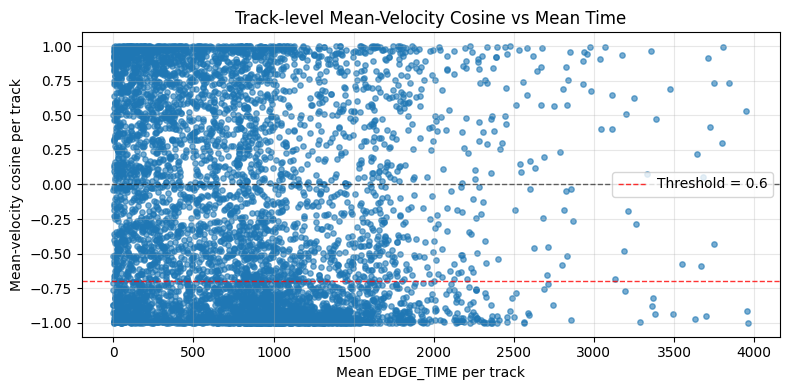

In [33]:
# Mean-velocity cosine vs mean EDGE_TIME per track
track_time_mean = merged.groupby('TRACK_ID')['EDGE_TIME'].mean()

common_ids = track_mean_vel.index.intersection(track_time_mean.index)
cos_track = track_mean_vel.loc[common_ids, 'cos_mean_velocity']
mean_time = track_time_mean.loc[common_ids]

plt.figure(figsize=(8, 4))
plt.scatter(mean_time, cos_track, s=15, alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(threshold, color='red', linestyle='--', linewidth=1, alpha=0.8, label='Threshold = 0.6')
plt.xlabel('Mean EDGE_TIME per track')
plt.ylabel('Mean-velocity cosine per track')
plt.title('Track-level Mean-Velocity Cosine vs Mean Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

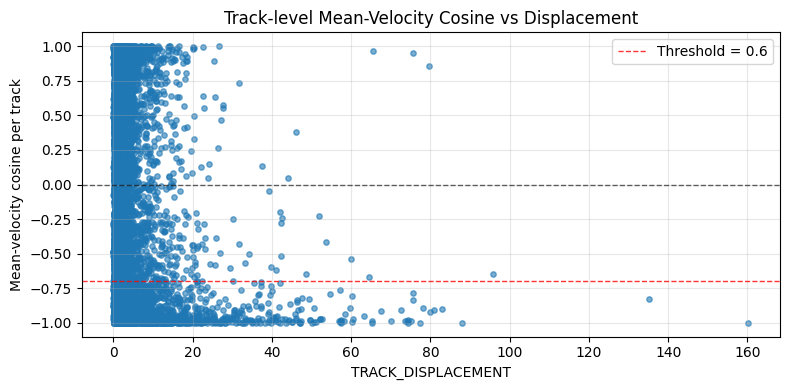

In [34]:
try:
    tracks_path = 'results/trial_5/highdensity_tracks.csv'
    tracks = pd.read_csv(tracks_path, header=0, skiprows=[1, 2, 3])
    disp = tracks.set_index('TRACK_ID')['TRACK_DISPLACEMENT']

    common_ids_disp = track_mean_vel.index.intersection(disp.index)
    cos_track_disp = track_mean_vel.loc[common_ids_disp, 'cos_mean_velocity']
    displacement = disp.loc[common_ids_disp]

    plt.figure(figsize=(8, 4))
    plt.scatter(displacement, cos_track_disp, s=15, alpha=0.6)
    plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
    plt.axhline(threshold, color='red', linestyle='--', linewidth=1, alpha=0.8, label='Threshold = 0.6')
    plt.xlabel('TRACK_DISPLACEMENT')
    plt.ylabel('Mean-velocity cosine per track')
    plt.title('Track-level Mean-Velocity Cosine vs Displacement')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Could not load tracks displacement: {e}')

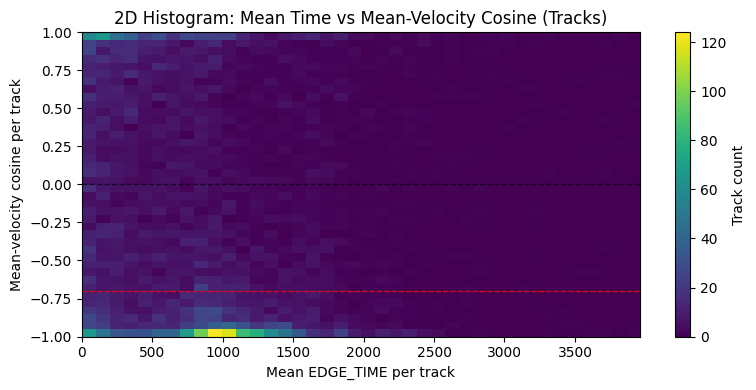

In [35]:
# 2D histogram: Mean-velocity cosine vs mean EDGE_TIME (density view)

cos_track = track_mean_vel['cos_mean_velocity'].dropna()
track_time_mean = merged.groupby('TRACK_ID')['EDGE_TIME'].mean().loc[cos_track.index]

# Define bins
n_time_bins = 40
n_cos_bins = 40

H_mv, time_edges_mv, cos_edges_mv = np.histogram2d(
    track_time_mean.values,
    cos_track.values,
    bins=[n_time_bins, n_cos_bins],
)

plt.figure(figsize=(8, 4))
plt.imshow(
    H_mv.T,
    aspect='auto',
    origin='lower',
    extent=[time_edges_mv[0], time_edges_mv[-1], cos_edges_mv[0], cos_edges_mv[-1]],
    cmap='viridis',
)
plt.colorbar(label='Track count')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(threshold, color='red', linestyle='--', linewidth=1, alpha=0.8, label='Threshold = 0.6')
plt.xlabel('Mean EDGE_TIME per track')
plt.ylabel('Mean-velocity cosine per track')
plt.title('2D Histogram: Mean Time vs Mean-Velocity Cosine (Tracks)')
plt.tight_layout()
plt.show()

### Longest Track Analysis 
- Mean Per-Track Cosine vs Per-Edge Mean Cosine

In [36]:
# tracks_path = 'results/trial_5/highdensity_tracks.csv'
tracks = pd.read_csv(tracks_path, header=0, skiprows=[1, 2, 3])
longest_track_id = tracks.sort_values('TRACK_DISPLACEMENT', ascending=False).head()['TRACK_ID'].iloc[0]

In [37]:
longest_track = merged[merged['TRACK_ID'] == longest_track_id].sort_values('EDGE_TIME')
longest_V_x = (
    (longest_track['POSITION_X_target'].iloc[-1] - 
    longest_track['POSITION_X_source'].iloc[0]) / 
    np.ptp(longest_track['EDGE_TIME'])
)
longest_V_y = (
    (longest_track['POSITION_Y_target'].iloc[-1] - 
    longest_track['POSITION_Y_source'].iloc[0]) / 
    np.ptp(longest_track['EDGE_TIME'])
)

longest_V_magnitude = np.sqrt(longest_V_x**2 + longest_V_y**2)
longest_V_x_unit = longest_V_x / longest_V_magnitude
longest_V_y_unit = longest_V_y / longest_V_magnitude

# Dot product with wave unit vector
print(f'Longest track wave alignment: {longest_V_x_unit * wave_x_unit + longest_V_y_unit * wave_y_unit}')

Longest track wave alignment: -0.47734118328844394


In [38]:
longest_cos_mean_velocity = track_mean_vel.loc[longest_track_id]['cos_mean_velocity']
print(
    f'Longest track wave alignment (on average): {longest_cos_mean_velocity}'
)

Longest track wave alignment (on average): -0.9989219685096186


As expected, mean track velocity cosine more accurately depicts a track's average direction alignment with the wave.

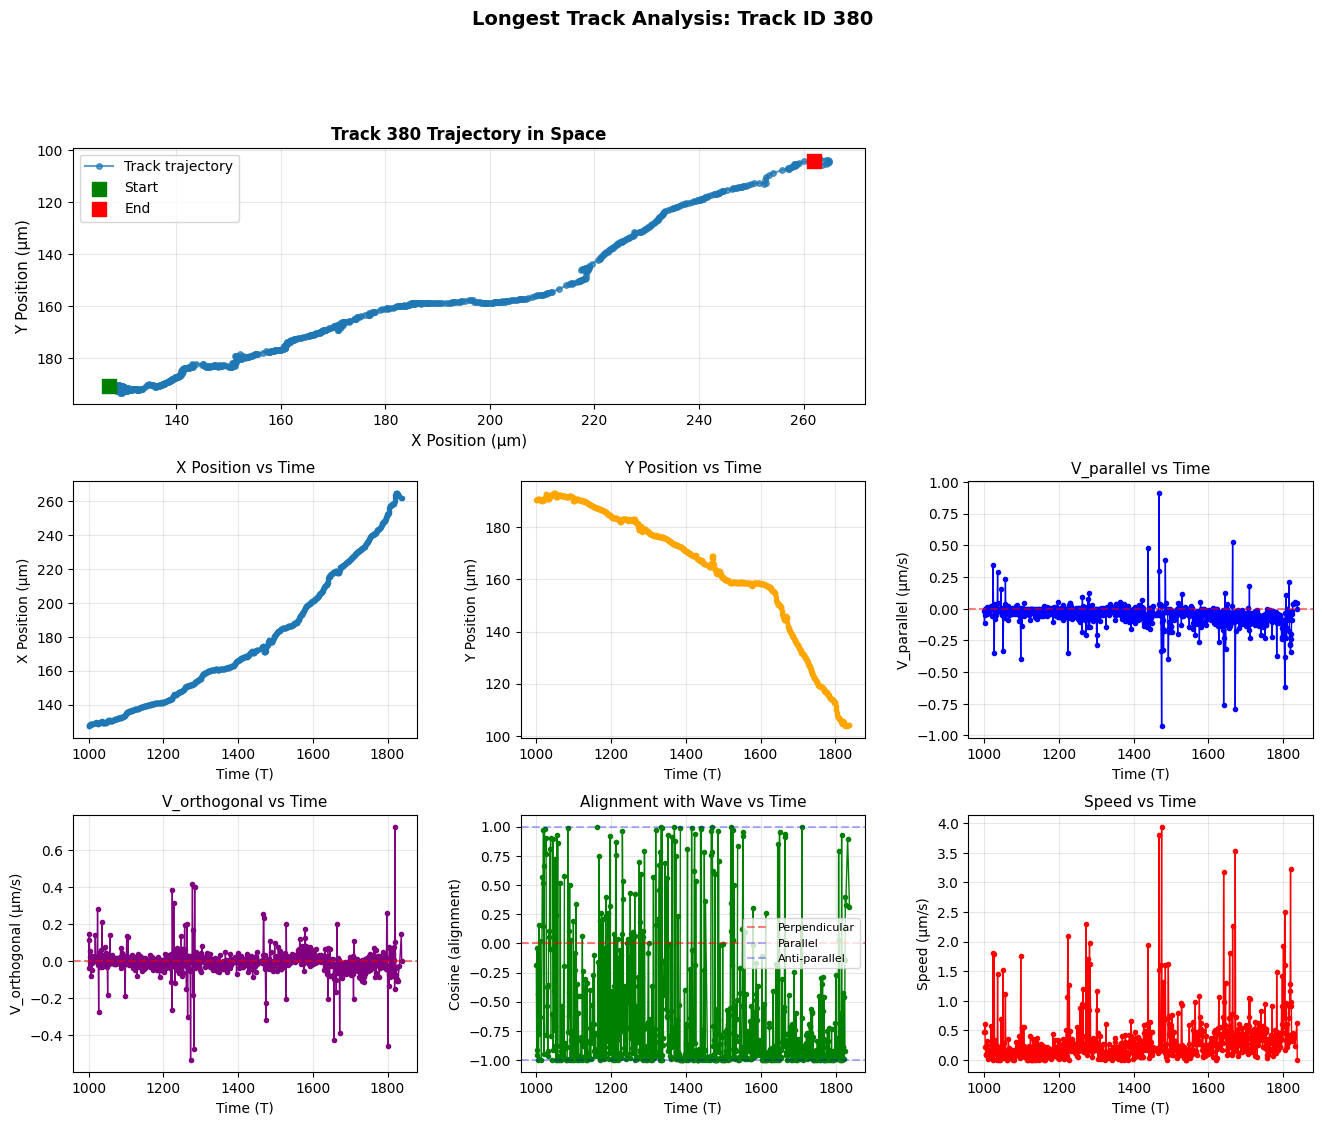

Track 380 Summary:
Edges: 818
Time range: 1000.0 - 1838.0
Displacement: 160.19 μm
Mean V_parallel: -0.048 μm/s
Mean V_orthogonal: -0.003 μm/s
Mean cosine: -0.598
Mean speed: 0.329 μm/s



In [39]:
# Visualize longest track - comprehensive view
longest_track = merged[merged['TRACK_ID'] == longest_track_id].copy().sort_values('EDGE_TIME' if 'EDGE_TIME' in merged.columns else 'POSITION_T_source')

# Get time axis
if 'EDGE_TIME' in longest_track.columns:
    T_track = longest_track['EDGE_TIME']
else:
    T_track = (longest_track['POSITION_T_source'] + longest_track['POSITION_T_target']) / 2

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Trajectory in X-Y space (top-left, spans 2 columns)
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(longest_track['EDGE_X_LOCATION'], longest_track['EDGE_Y_LOCATION'], 
         'o-', markersize=4, linewidth=1.5, alpha=0.7, label='Track trajectory')
ax1.scatter(longest_track['EDGE_X_LOCATION'].iloc[0], longest_track['EDGE_Y_LOCATION'].iloc[0],
           s=100, color='green', marker='s', label='Start', zorder=5)
ax1.scatter(longest_track['EDGE_X_LOCATION'].iloc[-1], longest_track['EDGE_Y_LOCATION'].iloc[-1],
           s=100, color='red', marker='s', label='End', zorder=5)
ax1.set_xlabel('X Position (μm)', fontsize=11)
ax1.set_ylabel('Y Position (μm)', fontsize=11)
ax1.set_title(f'Track {longest_track_id} Trajectory in Space', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()  # Image coordinates: Y increases downward

# 2. Position X vs Time (middle-left)
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(T_track, longest_track['EDGE_X_LOCATION'], 'o-', markersize=3, linewidth=1)
ax2.set_xlabel('Time (T)', fontsize=10)
ax2.set_ylabel('X Position (μm)', fontsize=10)
ax2.set_title('X Position vs Time', fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Position Y vs Time (middle-center)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(T_track, longest_track['EDGE_Y_LOCATION'], 'o-', markersize=3, linewidth=1, color='orange')
ax3.set_xlabel('Time (T)', fontsize=10)
ax3.set_ylabel('Y Position (μm)', fontsize=10)
ax3.set_title('Y Position vs Time', fontsize=11)
ax3.grid(True, alpha=0.3)

# 4. V_parallel vs Time (middle-right)
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(T_track, longest_track['V_parallel'], 'o-', markersize=3, linewidth=1, color='blue')
ax4.axhline(0, color='red', linestyle='--', alpha=0.5)
ax4.set_xlabel('Time (T)', fontsize=10)
ax4.set_ylabel('V_parallel (μm/s)', fontsize=10)
ax4.set_title('V_parallel vs Time', fontsize=11)
ax4.grid(True, alpha=0.3)

# 5. V_orthogonal vs Time (bottom-left)
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(T_track, longest_track['V_orthogonal'], 'o-', markersize=3, linewidth=1, color='purple')
ax5.axhline(0, color='red', linestyle='--', alpha=0.5)
ax5.set_xlabel('Time (T)', fontsize=10)
ax5.set_ylabel('V_orthogonal (μm/s)', fontsize=10)
ax5.set_title('V_orthogonal vs Time', fontsize=11)
ax5.grid(True, alpha=0.3)

# 6. Cosine (alignment) vs Time (bottom-center)
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(T_track, longest_track['cosine'], 'o-', markersize=3, linewidth=1, color='green')
ax6.axhline(0, color='red', linestyle='--', alpha=0.5, label='Perpendicular')
ax6.axhline(1, color='blue', linestyle='--', alpha=0.3, label='Parallel')
ax6.axhline(-1, color='blue', linestyle='--', alpha=0.3, label='Anti-parallel')
ax6.set_xlabel('Time (T)', fontsize=10)
ax6.set_ylabel('Cosine (alignment)', fontsize=10)
ax6.set_title('Alignment with Wave vs Time', fontsize=11)
ax6.set_ylim(-1.1, 1.1)
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Speed vs Time (bottom-right)
ax7 = fig.add_subplot(gs[2, 2])
ax7.plot(T_track, longest_track['SPEED'], 'o-', markersize=3, linewidth=1, color='red')
ax7.set_xlabel('Time (T)', fontsize=10)
ax7.set_ylabel('Speed (μm/s)', fontsize=10)
ax7.set_title('Speed vs Time', fontsize=11)
ax7.grid(True, alpha=0.3)

plt.suptitle(f'Longest Track Analysis: Track ID {longest_track_id}', fontsize=14, fontweight='bold', y=0.995)
plt.show()

# Add summary text
track_info = f"""Track {longest_track_id} Summary:
{'='*40}
Edges: {len(longest_track)}
Time range: {T_track.min():.1f} - {T_track.max():.1f}
Displacement: {tracks[tracks['TRACK_ID']==longest_track_id]['TRACK_DISPLACEMENT'].iloc[0]:.2f} μm
Mean V_parallel: {longest_track['V_parallel'].mean():.3f} μm/s
Mean V_orthogonal: {longest_track['V_orthogonal'].mean():.3f} μm/s
Mean cosine: {longest_track['cosine'].mean():.3f}
Mean speed: {longest_track['SPEED'].mean():.3f} μm/s
"""
print(track_info)

### 3D Unimodal Per Track Density Visualization

When plotting the density surface of the cosines of the mean track velocities, we get a more unimodal distribution, peaking at -1 instead of both -1 and +1. It most likely follows that the tracks moving exactly parallel in the direction of the wave (+1) could exhibit concentrated noise.

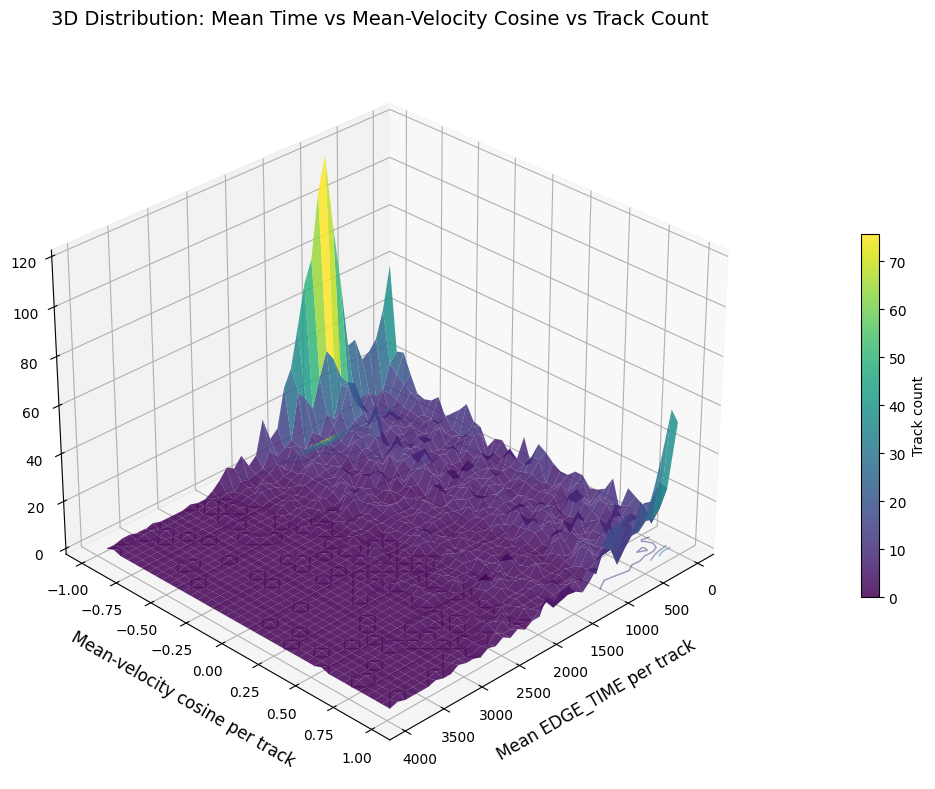

Track-level 3D distribution stats:
Tracks used: 6026
Mean-velocity cosine range: [-1.000, 1.000]
Mean EDGE_TIME range: [0.0, 3963.9]
Max bin count: 120.0 (tracks)
Bins with data: 926 / 1600


In [40]:
from utils import plot_mean_velocity_cosine_3d

plot_mean_velocity_cosine_3d(track_mean_vel, merged)

# Velocities With Respect to Slug Centroid

This poses a greater challenge than the wave vector analysis, as the wave vector was **fixed**, rather than **dynamic**. In this case, the centroid direction is different for **every cell** and **every time** (the vector from centroid to cell changes), so:
- We must recompute $\hat{r}$ for each edge
- The geometry is radial (like gravity) rather than translational

In [41]:
# this is the (image) coordinate of the main final centroid in our ROI
centroid_x = 270
centroid_y = 309 

In [42]:
# get actual computed center point (last remaining track)
centroid_x, centroid_y = (
    np.array(
        merged.sort_values(by='EDGE_TIME', ascending=False)
            [['POSITION_X_target', 'POSITION_Y_target']]
            .iloc[0]
    )
)
print(centroid_x, centroid_y)

365.86 67.796


### 1. Compute distance vector
We compute the radial vector (of cell positions w.r.t. the centroid) for each cell at every time.

In [43]:
merged['dx_centroid'] = merged['EDGE_X_LOCATION'] - centroid_x
merged['dy_centroid'] = merged['EDGE_Y_LOCATION'] - centroid_y
merged['dy_centroid'] = merged['dy_centroid'] * -1 # convert to math coords

# Radial distance from centroid
merged['r_centroid'] = np.sqrt(merged['dx_centroid']**2 + merged['dy_centroid']**2)

In [44]:
merged.head()

,LABEL,TRACK_ID,SPOT_SOURCE_ID,SPOT_TARGET_ID,LINK_COST,DIRECTIONAL_CHANGE_RATE,SPEED,DISPLACEMENT,EDGE_TIME,EDGE_X_LOCATION,...,V_x,V_y,VELOCITY,cosine,V_parallel,V_orthogonal,time_bin,dx_centroid,dy_centroid,r_centroid
0,ID8828 → ID8877,0,8877,8828,0.010385,2.168411,0.196958,0.196958,3361.0,282.778894,...,0.034622,0.034666,0.196958,-0.961491,-0.047107,-0.013541,42,-83.081106,-1.766104,83.099876
1,ID8854 → ID8828,0,8828,8854,0.589797,2.265405,0.364018,0.364018,3362.0,282.882576,...,0.016960,-0.088948,0.364018,0.312526,0.028300,0.086056,42,-82.977424,-1.875212,82.998611
2,ID8806 → ID8854,0,8854,8806,0.395159,2.969275,0.353423,0.353423,3363.0,283.028846,...,0.055810,0.067929,0.353423,-0.930206,-0.081779,-0.032370,42,-82.831154,-1.917462,82.853345
3,ID8900 → ID8806,0,8806,8900,1.611157,2.954880,0.222725,0.222725,3364.0,283.056624,...,-0.041991,-0.036144,0.222725,0.979562,0.054271,0.011260,42,-82.803376,-1.853573,82.824120
4,ID8822 → ID8900,0,8900,8822,0.410993,1.368130,0.268160,0.268160,3365.0,283.088312,...,0.057756,0.033376,0.268160,-1.000265,-0.066724,-0.001192,42,-82.771688,-1.859136,82.792564


### 2. Convert raw distance to unit vector

In [45]:
# Avoid division by zero
eps = 1e-9
merged['r_safe'] = merged['r_centroid'].clip(lower=eps)

# Radial unit components
merged['r_hat_x'] = merged['dx_centroid'] / merged['r_safe']
merged['r_hat_y'] = merged['dy_centroid'] / merged['r_safe']

# Tangential unit vector: rotate radial by +90° in ImageJ coords
# (x, y) -> (-y, x) gives a perpendicular vector
merged['t_hat_x'] = -merged['r_hat_y']
merged['t_hat_y'] =  merged['r_hat_x']

In [46]:
merged.head()

,LABEL,TRACK_ID,SPOT_SOURCE_ID,SPOT_TARGET_ID,LINK_COST,DIRECTIONAL_CHANGE_RATE,SPEED,DISPLACEMENT,EDGE_TIME,EDGE_X_LOCATION,...,V_orthogonal,time_bin,dx_centroid,dy_centroid,r_centroid,r_safe,r_hat_x,r_hat_y,t_hat_x,t_hat_y
0,ID8828 → ID8877,0,8877,8828,0.010385,2.168411,0.196958,0.196958,3361.0,282.778894,...,-0.013541,42,-83.081106,-1.766104,83.099876,83.099876,-0.999774,-0.021253,0.021253,-0.999774
1,ID8854 → ID8828,0,8828,8854,0.589797,2.265405,0.364018,0.364018,3362.0,282.882576,...,0.086056,42,-82.977424,-1.875212,82.998611,82.998611,-0.999745,-0.022593,0.022593,-0.999745
2,ID8806 → ID8854,0,8854,8806,0.395159,2.969275,0.353423,0.353423,3363.0,283.028846,...,-0.032370,42,-82.831154,-1.917462,82.853345,82.853345,-0.999732,-0.023143,0.023143,-0.999732
3,ID8900 → ID8806,0,8806,8900,1.611157,2.954880,0.222725,0.222725,3364.0,283.056624,...,0.011260,42,-82.803376,-1.853573,82.824120,82.824120,-0.999750,-0.022380,0.022380,-0.999750
4,ID8822 → ID8900,0,8900,8822,0.410993,1.368130,0.268160,0.268160,3365.0,283.088312,...,-0.001192,42,-82.771688,-1.859136,82.792564,82.792564,-0.999748,-0.022455,0.022455,-0.999748


### 3. Project Radial and Tangential Velocities

In [47]:
# Radial velocity: component of v along r_hat
merged['v_radial'] = (
    merged['V_x'] * merged['r_hat_x'] +
    merged['V_y'] * merged['r_hat_y']
)

# Tangential velocity: component of v along t_hat
merged['v_tangential'] = (
    merged['V_x'] * merged['t_hat_x'] +
    merged['V_y'] * merged['t_hat_y']
)

## EDA

### Radial Distance and Velocity Analysis

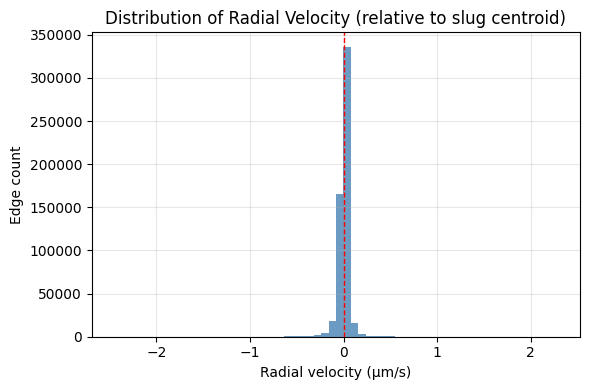

In [48]:
plt.figure(figsize=(6, 4))
plt.hist(merged['v_radial'], bins=60, color='steelblue', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Radial velocity (μm/s)')
plt.ylabel('Edge count')
plt.title('Distribution of Radial Velocity (relative to slug centroid)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

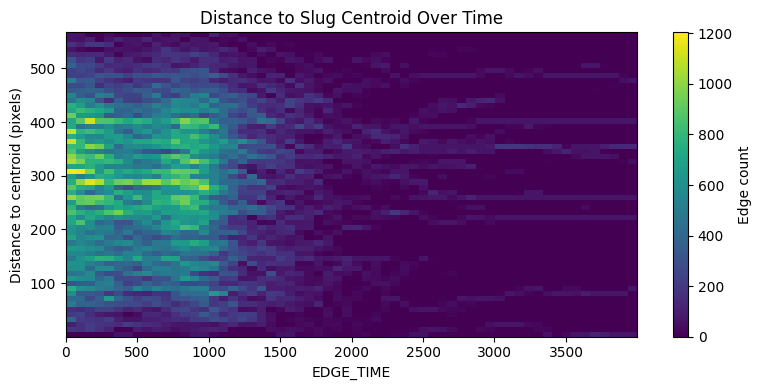

In [49]:
time_vals = merged['EDGE_TIME']
dist_vals = merged['r_centroid']

H, t_edges, r_edges = np.histogram2d(
    time_vals, dist_vals,
    bins=[60, 60]
)

plt.figure(figsize=(8, 4))
plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[t_edges[0], t_edges[-1], r_edges[0], r_edges[-1]],
    cmap='viridis'
)
plt.colorbar(label='Edge count')
plt.xlabel('EDGE_TIME')
plt.ylabel('Distance to centroid (pixels)')
plt.title('Distance to Slug Centroid Over Time')
plt.tight_layout()
plt.show()

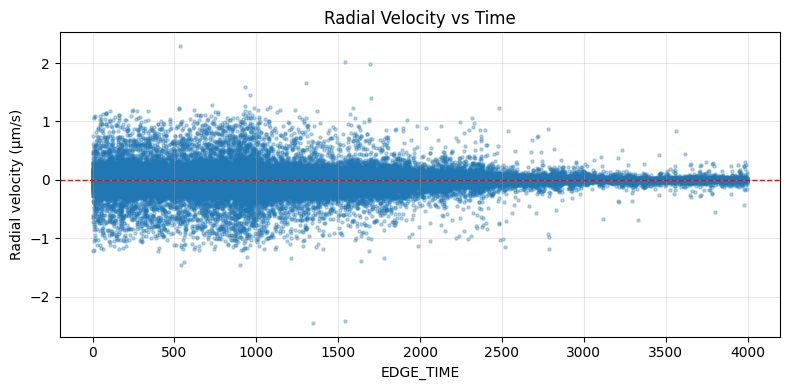

In [50]:
plt.figure(figsize=(8, 4))
plt.scatter(time_vals, merged['v_radial'], s=5, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('EDGE_TIME')
plt.ylabel('Radial velocity (μm/s)')
plt.title('Radial Velocity vs Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
track_stats = merged.groupby('TRACK_ID').agg({
    'v_radial': 'mean',
    'r_centroid': ['first', 'last', 'mean']
})

track_stats.columns = ['v_radial_mean', 'r_initial', 'r_final', 'r_mean']
track_stats = track_stats.reset_index()

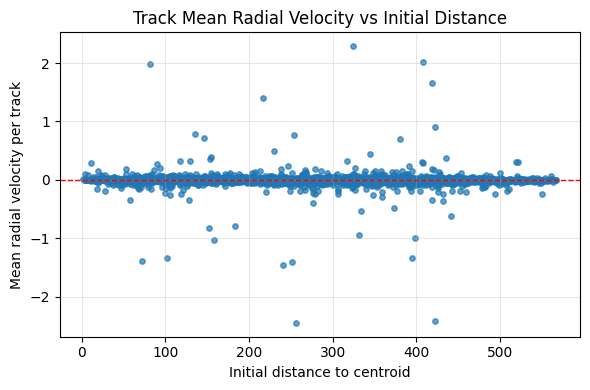

In [52]:
plt.figure(figsize=(6, 4))
plt.scatter(track_stats['r_initial'], track_stats['v_radial_mean'], s=15, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Initial distance to centroid')
plt.ylabel('Mean radial velocity per track')
plt.title('Track Mean Radial Velocity vs Initial Distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Radial Cosine Analysis

In [53]:
velocity_magnitude = np.sqrt(V_x**2 + V_y**2)

# Unit velocity components
merged['V_hat_x'] = merged['V_x'] / velocity_magnitude
merged['V_hat_y'] = merged['V_y'] / velocity_magnitude

# Radial cosine: alignment of velocity with radial direction from centroid
merged['radial_cosine'] = (
    merged['V_hat_x'] * merged['r_hat_x'] +
    merged['V_hat_y'] * merged['r_hat_y']
)

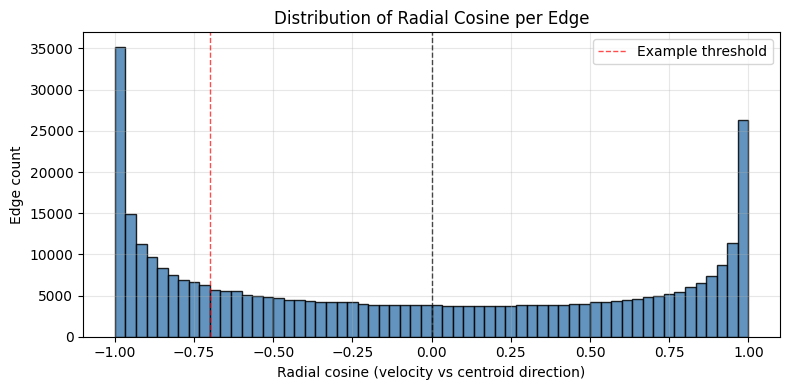

In [54]:
plt.figure(figsize=(8, 4))
plt.hist(merged['radial_cosine'].dropna(), bins=60, range=(-1, 1),
         color='steelblue', alpha=0.85, edgecolor='black')
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.axvline(-0.7, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Example threshold')
plt.xlabel('Radial cosine (velocity vs centroid direction)')
plt.ylabel('Edge count')
plt.title('Distribution of Radial Cosine per Edge')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

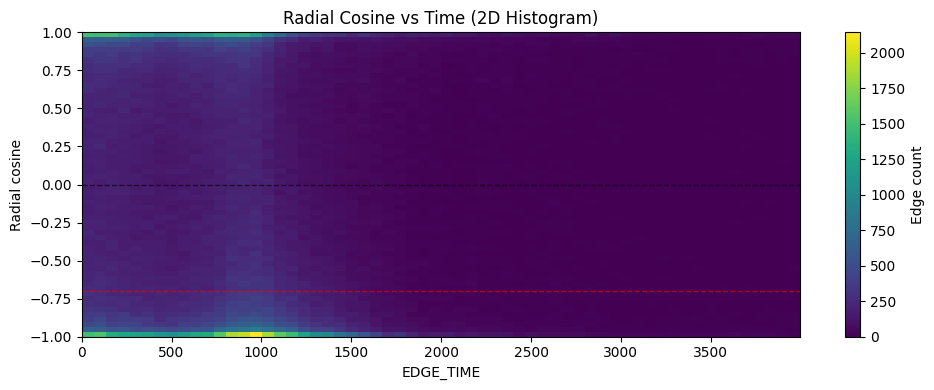

In [55]:
time_vals = merged['EDGE_TIME'].values
cos_vals  = merged['radial_cosine'].values

n_time_bins = 60
n_cos_bins  = 60

time_bins = np.linspace(time_vals.min(), time_vals.max(), n_time_bins + 1)
cos_bins  = np.linspace(-1, 1, n_cos_bins + 1)

H, t_edges, c_edges = np.histogram2d(time_vals, cos_vals, bins=[time_bins, cos_bins])

plt.figure(figsize=(10, 4))
plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[t_edges[0], t_edges[-1], c_edges[0], c_edges[-1]],
    cmap='viridis'
)
plt.colorbar(label='Edge count')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(-0.7, color='red', linestyle='--', linewidth=1, alpha=0.6)
plt.xlabel('EDGE_TIME')
plt.ylabel('Radial cosine')
plt.title('Radial Cosine vs Time (2D Histogram)')
plt.tight_layout()
plt.show()

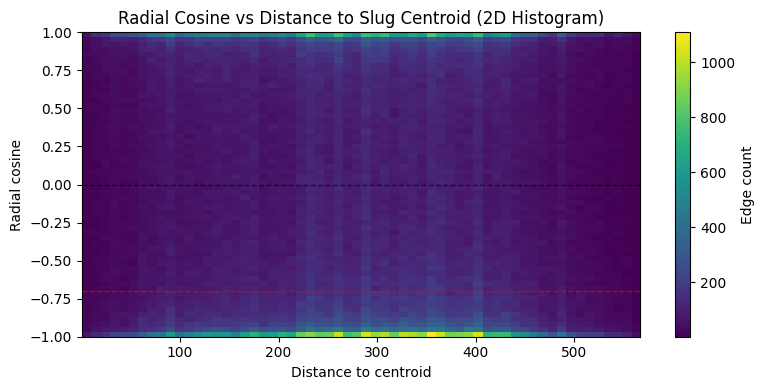

In [56]:
dist_vals = merged['r_centroid'].values
cos_vals  = merged['radial_cosine'].values

n_dist_bins = 60
n_cos_bins  = 60

dist_bins = np.linspace(dist_vals.min(), dist_vals.max(), n_dist_bins + 1)
cos_bins  = np.linspace(-1, 1, n_cos_bins + 1)

H_dc, d_edges, c_edges = np.histogram2d(dist_vals, cos_vals, bins=[dist_bins, cos_bins])

plt.figure(figsize=(8, 4))
plt.imshow(
    H_dc.T,
    aspect='auto',
    origin='lower',
    extent=[d_edges[0], d_edges[-1], c_edges[0], c_edges[-1]],
    cmap='viridis'
)
plt.colorbar(label='Edge count')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(-0.7, color='red', linestyle='--', linewidth=1, alpha=0.6)
plt.xlabel('Distance to centroid')
plt.ylabel('Radial cosine')
plt.title('Radial Cosine vs Distance to Slug Centroid (2D Histogram)')
plt.tight_layout()
plt.show()

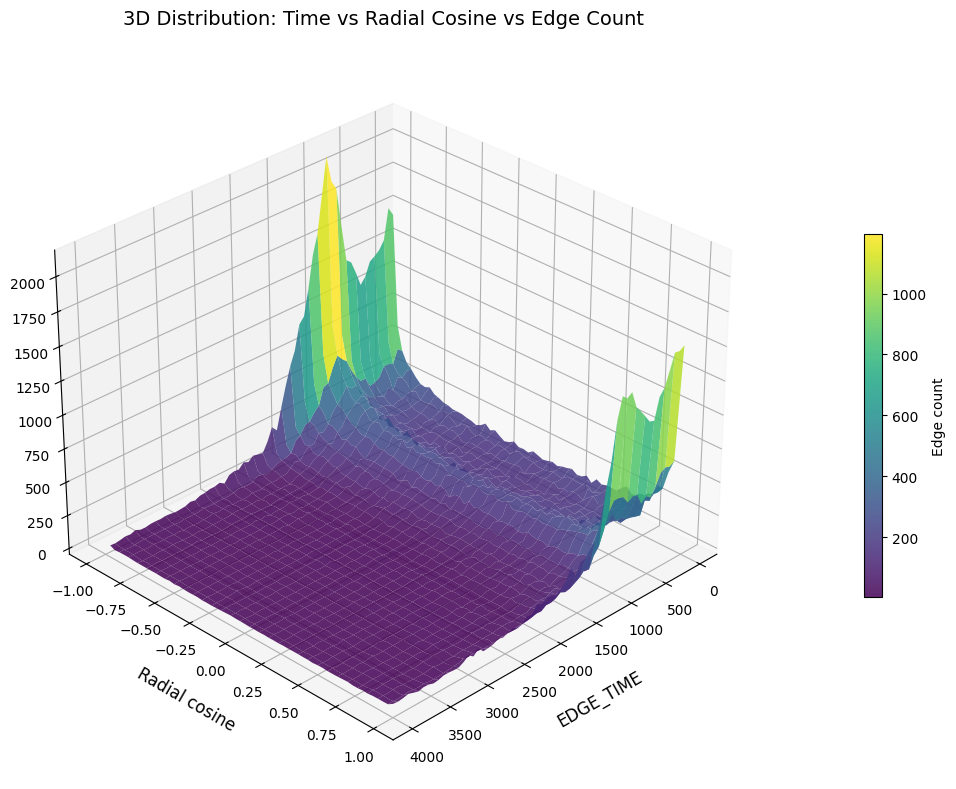

In [57]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Reuse H, t_edges, c_edges from the time vs cosine 2D histogram above
T_centers = (t_edges[:-1] + t_edges[1:]) / 2
C_centers = (c_edges[:-1] + c_edges[1:]) / 2
T_mesh, C_mesh = np.meshgrid(T_centers, C_centers, indexing='ij')

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    T_mesh, C_mesh, H,
    cmap='viridis',
    alpha=0.85,
    linewidth=0,
    antialiased=True
)

ax.set_xlabel('EDGE_TIME', fontsize=12, labelpad=10)
ax.set_ylabel('Radial cosine', fontsize=12, labelpad=10)
ax.set_zlabel('Edge count', fontsize=12, labelpad=10)
ax.set_title('3D Distribution: Time vs Radial Cosine vs Edge Count', fontsize=14, pad=20)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20, pad=0.1, label='Edge count')
ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

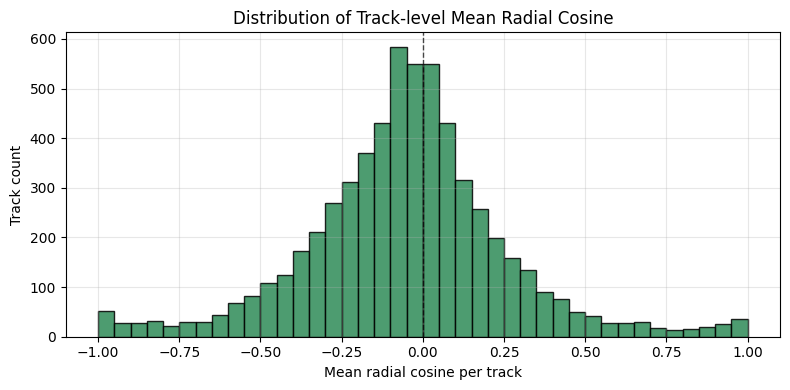

In [58]:
track_radial_cos = merged.groupby('TRACK_ID')['radial_cosine'].mean().dropna()

plt.figure(figsize=(8, 4))
plt.hist(track_radial_cos, bins=40, range=(-1, 1),
         color='seagreen', alpha=0.85, edgecolor='black')
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('Mean radial cosine per track')
plt.ylabel('Track count')
plt.title('Distribution of Track-level Mean Radial Cosine')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Radial Acceleration w.r.t Centroids

In [59]:
merged_sorted = merged.sort_values(['TRACK_ID', 'EDGE_TIME']).copy()
merged_sorted.head()

,LABEL,TRACK_ID,SPOT_SOURCE_ID,SPOT_TARGET_ID,LINK_COST,DIRECTIONAL_CHANGE_RATE,SPEED,DISPLACEMENT,EDGE_TIME,EDGE_X_LOCATION,...,r_safe,r_hat_x,r_hat_y,t_hat_x,t_hat_y,v_radial,v_tangential,V_hat_x,V_hat_y,radial_cosine
0,ID8828 → ID8877,0,8877,8828,0.010385,2.168411,0.196958,0.196958,3361.0,282.778894,...,83.099876,-0.999774,-0.021253,0.021253,-0.999774,-0.035351,-0.033922,0.706659,0.707554,-0.721537
1,ID8854 → ID8828,0,8828,8854,0.589797,2.265405,0.364018,0.364018,3362.0,282.882576,...,82.998611,-0.999745,-0.022593,0.022593,-0.999745,-0.014947,0.089309,0.187303,-0.982302,-0.165062
2,ID8806 → ID8854,0,8854,8806,0.395159,2.969275,0.353423,0.353423,3363.0,283.028846,...,82.853345,-0.999732,-0.023143,0.023143,-0.999732,-0.057367,-0.066619,0.634817,0.772663,-0.652528
3,ID8900 → ID8806,0,8806,8900,1.611157,2.954880,0.222725,0.222725,3364.0,283.056624,...,82.824120,-0.999750,-0.022380,0.022380,-0.999750,0.042789,0.035195,-0.757901,-0.652370,0.772311
4,ID8822 → ID8900,0,8900,8822,0.410993,1.368130,0.268160,0.268160,3365.0,283.088312,...,82.792564,-0.999748,-0.022455,0.022455,-0.999748,-0.058491,-0.032070,0.865827,0.500343,-0.876844


### 1. Compute Radial Velocity and Time Differences at $i$ and $i-1$

In [60]:
# Group by track and compute differences

# at row i, give v_radial from row i-1
merged_sorted['v_radial_prev'] = merged_sorted.groupby('TRACK_ID')['v_radial'].shift(1) 

# get difference of edge time with i and i-1th row
merged_sorted['delta_t'] = merged_sorted.groupby('TRACK_ID')['EDGE_TIME'].diff()

# Radial acceleration = change in radial velocity / change in time
# Avoid division by zero
eps = 1e-9
delta_t_safe = merged_sorted['delta_t'].clip(lower=eps)

merged_sorted['a_radial'] = (
    (merged_sorted['v_radial'] - merged_sorted['v_radial_prev']) / delta_t_safe
)

In [61]:
# These should be True for all rows
nan_mask = merged_sorted['delta_t'].isna()
print(f"Rows where delta_t is NaN: {nan_mask.sum()}")

# Check if v_radial_prev is also NaN at those same rows
print(f"v_radial_prev NaN at same rows: {merged_sorted.loc[nan_mask, 'v_radial_prev'].isna().sum()}")

# Should also verify these are the first edge of each track
first_edges = merged_sorted.groupby('TRACK_ID').head(1)
print(f"Number of tracks: {merged_sorted['TRACK_ID'].nunique()}")
print(f"First edges have delta_t NaN: {(first_edges['delta_t'].isna()).sum()}")

Rows where delta_t is NaN: 6234
v_radial_prev NaN at same rows: 6234
Number of tracks: 6234
First edges have delta_t NaN: 6234


In [62]:
# Set first edge of each track to NaN (no previous edge to compare)
merged_sorted.loc[merged_sorted['delta_t'].isna(), 'a_radial'] = np.nan

### 2. Remove Outliers / Jumps

In [63]:
# Remove top N outliers by absolute acceleration
N = 1  # adjust as needed
outlier_indices = merged_sorted['a_radial'].abs().nlargest(N).index

print(f"Removing {len(outlier_indices)} outliers:")
print(merged_sorted.loc[outlier_indices, ['TRACK_ID', 'EDGE_TIME', 'a_radial', 'r_centroid']])

merged_sorted = merged_sorted.drop(index=outlier_indices).copy()

Removing 1 outliers:
       TRACK_ID  EDGE_TIME      a_radial  r_centroid
79848      1029     1410.0  1.818874e+09  442.491508


## EDA

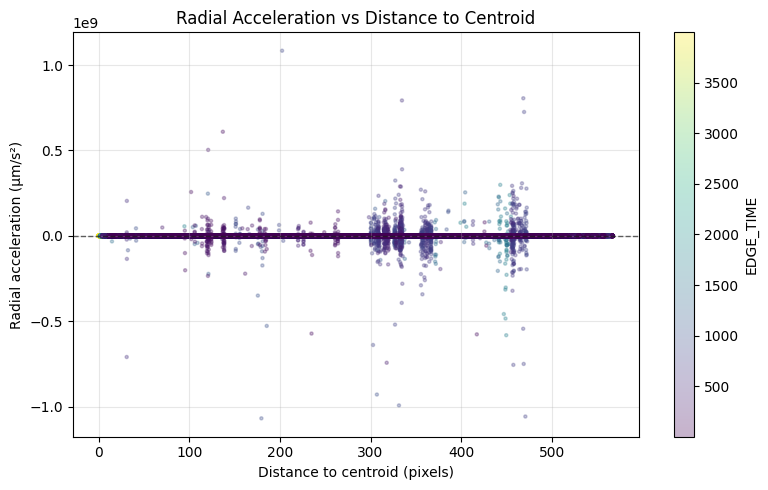

In [64]:
plt.figure(figsize=(8, 5))
plt.scatter(
    merged_sorted['r_centroid'],
    merged_sorted['a_radial'],
    s=5,
    alpha=0.3,
    c=merged_sorted['EDGE_TIME'],
    cmap='viridis'
)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.xlabel('Distance to centroid (pixels)')
plt.ylabel('Radial acceleration (μm/s²)')
plt.colorbar(label='EDGE_TIME')
plt.title('Radial Acceleration vs Distance to Centroid')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

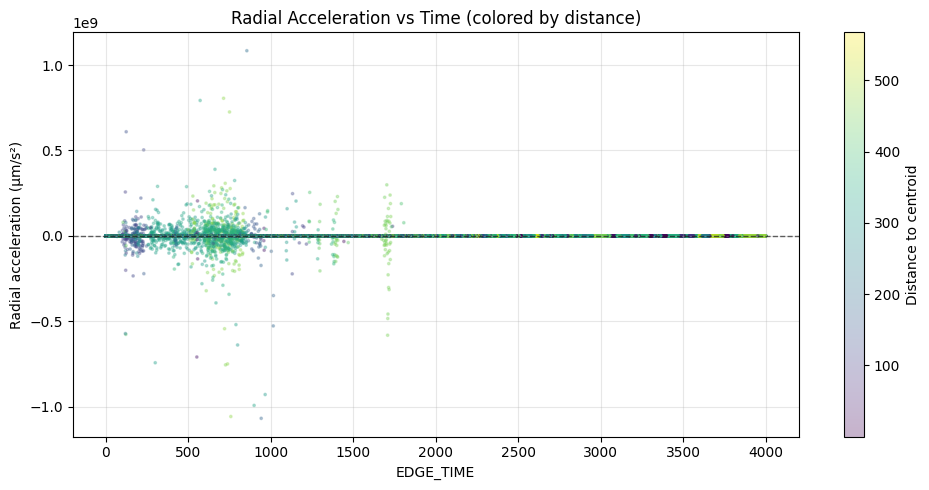

In [65]:
plt.figure(figsize=(10, 5))
plt.scatter(merged_sorted['EDGE_TIME'], merged_sorted['a_radial'], 
            s=3, alpha=0.3, c=merged_sorted['r_centroid'], cmap='viridis')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.xlabel('EDGE_TIME')
plt.ylabel('Radial acceleration (μm/s²)')
plt.colorbar(label='Distance to centroid')
plt.title('Radial Acceleration vs Time (colored by distance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

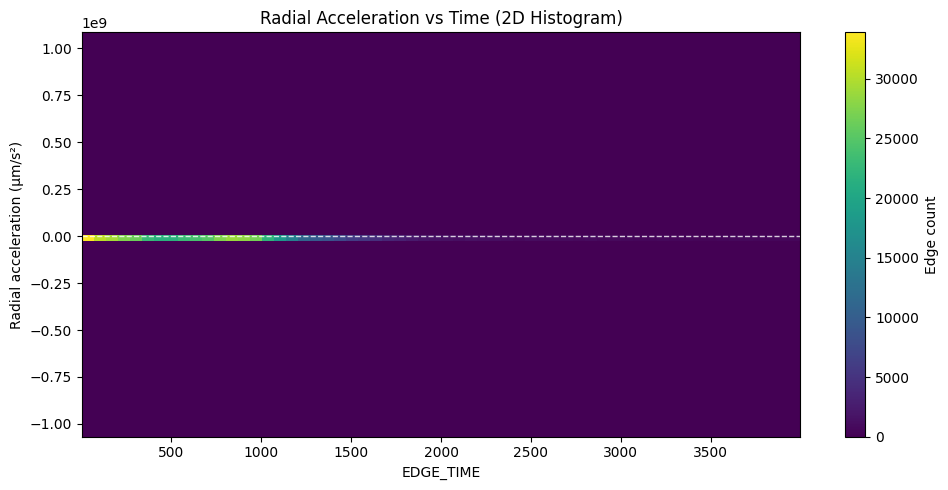

In [66]:
time_vals = merged_sorted['EDGE_TIME'].values
acc_vals = merged_sorted['a_radial'].dropna().values
time_vals_acc = merged_sorted.loc[merged_sorted['a_radial'].notna(), 'EDGE_TIME'].values

n_time_bins = 60
n_acc_bins = 60

time_bins = np.linspace(time_vals_acc.min(), time_vals_acc.max(), n_time_bins + 1)
acc_bins = np.linspace(acc_vals.min(), acc_vals.max(), n_acc_bins + 1)

H, t_edges, a_edges = np.histogram2d(time_vals_acc, acc_vals, bins=[time_bins, acc_bins])

plt.figure(figsize=(10, 5))
plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[t_edges[0], t_edges[-1], a_edges[0], a_edges[-1]],
    cmap='viridis'
)
plt.colorbar(label='Edge count')
plt.axhline(0, color='white', linestyle='--', linewidth=1, alpha=0.8)
plt.xlabel('EDGE_TIME')
plt.ylabel('Radial acceleration (μm/s²)')
plt.title('Radial Acceleration vs Time (2D Histogram)')
plt.tight_layout()
plt.show()

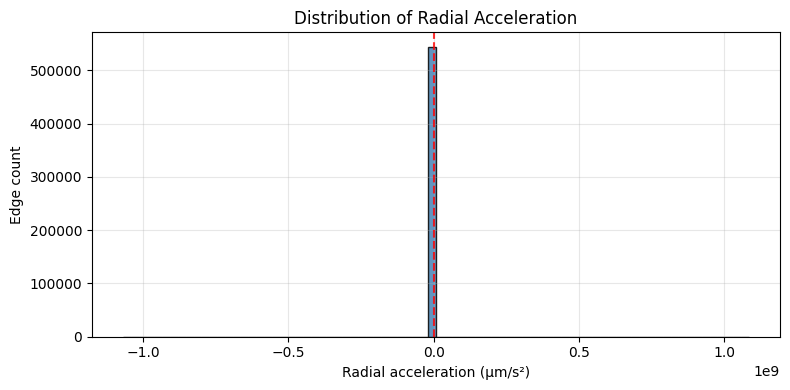

In [67]:
plt.figure(figsize=(8, 4))
plt.hist(merged_sorted['a_radial'].dropna(), bins=80, 
         color='steelblue', alpha=0.85, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
plt.xlabel('Radial acceleration (μm/s²)')
plt.ylabel('Edge count')
plt.title('Distribution of Radial Acceleration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

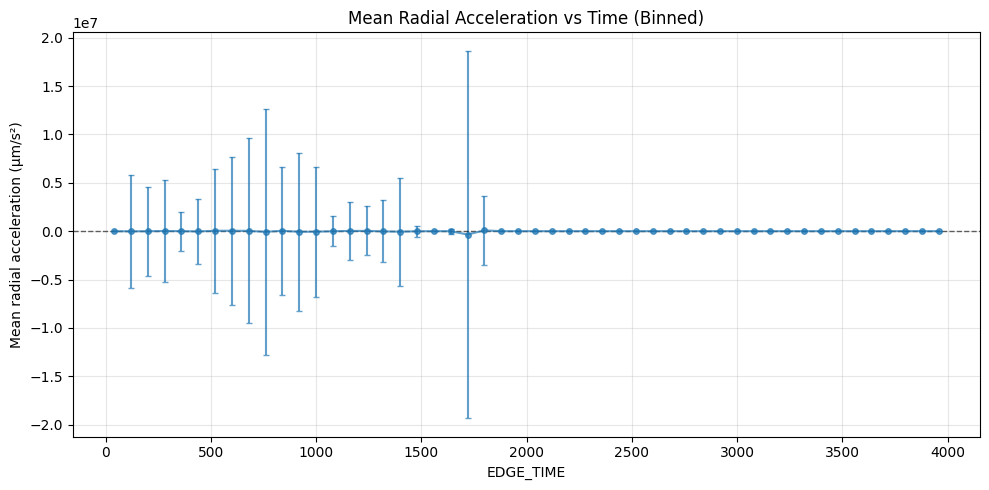

In [68]:
# Bin time and compute mean acceleration per bin
n_time_bins = 50
time_bins = np.linspace(merged_sorted['EDGE_TIME'].min(), 
                        merged_sorted['EDGE_TIME'].max(), 
                        n_time_bins + 1)
merged_sorted['time_bin'] = pd.cut(merged_sorted['EDGE_TIME'], bins=time_bins)

acc_by_time = merged_sorted.groupby('time_bin')['a_radial'].agg(['mean', 'std', 'count']).reset_index()
acc_by_time['time_center'] = acc_by_time['time_bin'].apply(lambda x: x.mid)

plt.figure(figsize=(10, 5))
plt.errorbar(
    acc_by_time['time_center'],
    acc_by_time['mean'],
    yerr=acc_by_time['std'],
    fmt='o-',
    capsize=2,
    alpha=0.7,
    markersize=4
)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.xlabel('EDGE_TIME')
plt.ylabel('Mean radial acceleration (μm/s²)')
plt.title('Mean Radial Acceleration vs Time (Binned)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

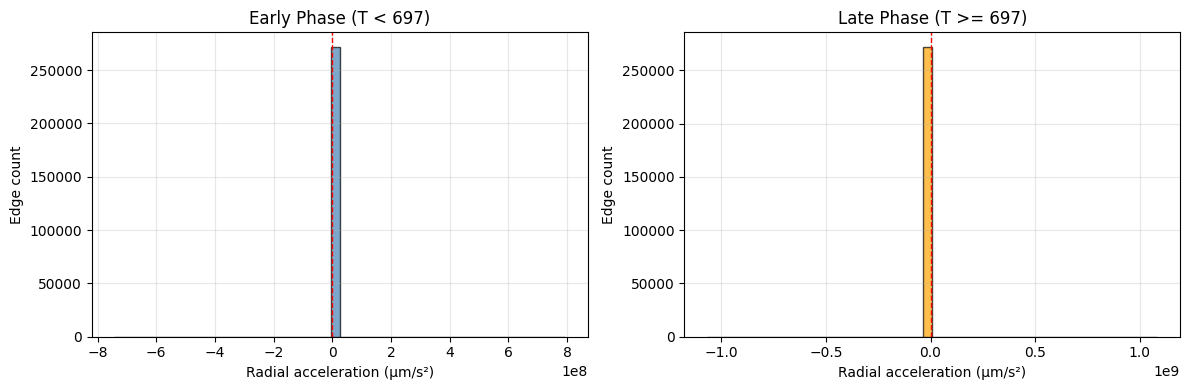

Early phase: mean = 5331.4257, std = 5229325.0488
Late phase:  mean = -19838.9950, std = 7159554.4267


In [69]:
# Split into early and late phases
time_median = merged_sorted['EDGE_TIME'].median()
early = merged_sorted[merged_sorted['EDGE_TIME'] < time_median]['a_radial'].dropna()
late = merged_sorted[merged_sorted['EDGE_TIME'] >= time_median]['a_radial'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(early, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Radial acceleration (μm/s²)')
axes[0].set_ylabel('Edge count')
axes[0].set_title(f'Early Phase (T < {time_median:.0f})')
axes[0].grid(True, alpha=0.3)

axes[1].hist(late, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Radial acceleration (μm/s²)')
axes[1].set_ylabel('Edge count')
axes[1].set_title(f'Late Phase (T >= {time_median:.0f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Early phase: mean = {early.mean():.4f}, std = {early.std():.4f}")
print(f"Late phase:  mean = {late.mean():.4f}, std = {late.std():.4f}")

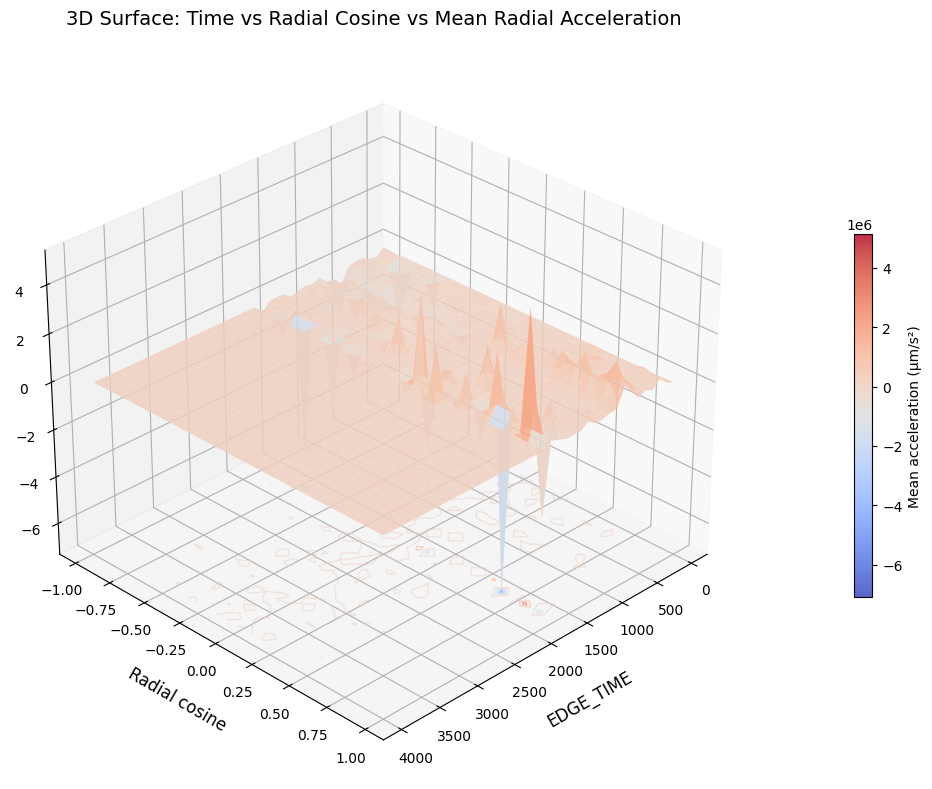

In [70]:
# Filter out NaN accelerations and radial cosine
acc_cos_data = merged_sorted[
    merged_sorted['a_radial'].notna() & 
    merged_sorted['radial_cosine'].notna()
].copy()

time_vals = acc_cos_data['EDGE_TIME'].values
cos_vals = acc_cos_data['radial_cosine'].values
acc_vals = acc_cos_data['a_radial'].values

# Create bins
n_time_bins = 40
n_cos_bins = 40

time_bins = np.linspace(time_vals.min(), time_vals.max(), n_time_bins + 1)
cos_bins = np.linspace(-1, 1, n_cos_bins + 1)

# 2D histogram: time vs radial cosine
H, t_edges, c_edges = np.histogram2d(time_vals, cos_vals, bins=[time_bins, cos_bins])

# Mean acceleration per bin
H_acc, _, _ = np.histogram2d(time_vals, cos_vals, bins=[time_bins, cos_bins], weights=acc_vals)
H_acc_mean = np.divide(H_acc, H, out=np.zeros_like(H_acc), where=H > 0)

# Bin centers
t_centers = (t_edges[:-1] + t_edges[1:]) / 2
c_centers = (c_edges[:-1] + c_edges[1:]) / 2
T_mesh, C_mesh = np.meshgrid(t_centers, c_centers, indexing='ij')

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    T_mesh, C_mesh, H_acc_mean,
    cmap='coolwarm',
    alpha=0.85,
    linewidth=0,
    antialiased=True,
    vmin=H_acc_mean[H > 0].min() if np.any(H > 0) else 0,
    vmax=H_acc_mean[H > 0].max() if np.any(H > 0) else 0,
)

ax.contour(
    T_mesh, C_mesh, H_acc_mean,
    zdir='z',
    offset=H_acc_mean[H > 0].min() if np.any(H > 0) else 0,
    cmap='coolwarm',
    alpha=0.5,
    linewidths=1,
)

ax.set_xlabel('EDGE_TIME', fontsize=12, labelpad=10)
ax.set_ylabel('Radial cosine', fontsize=12, labelpad=10)
ax.set_zlabel('Mean radial acceleration (μm/s²)', fontsize=12, labelpad=10)
ax.set_title('3D Surface: Time vs Radial Cosine vs Mean Radial Acceleration', fontsize=14, pad=20)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20, pad=0.1, label='Mean acceleration (μm/s²)')
ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

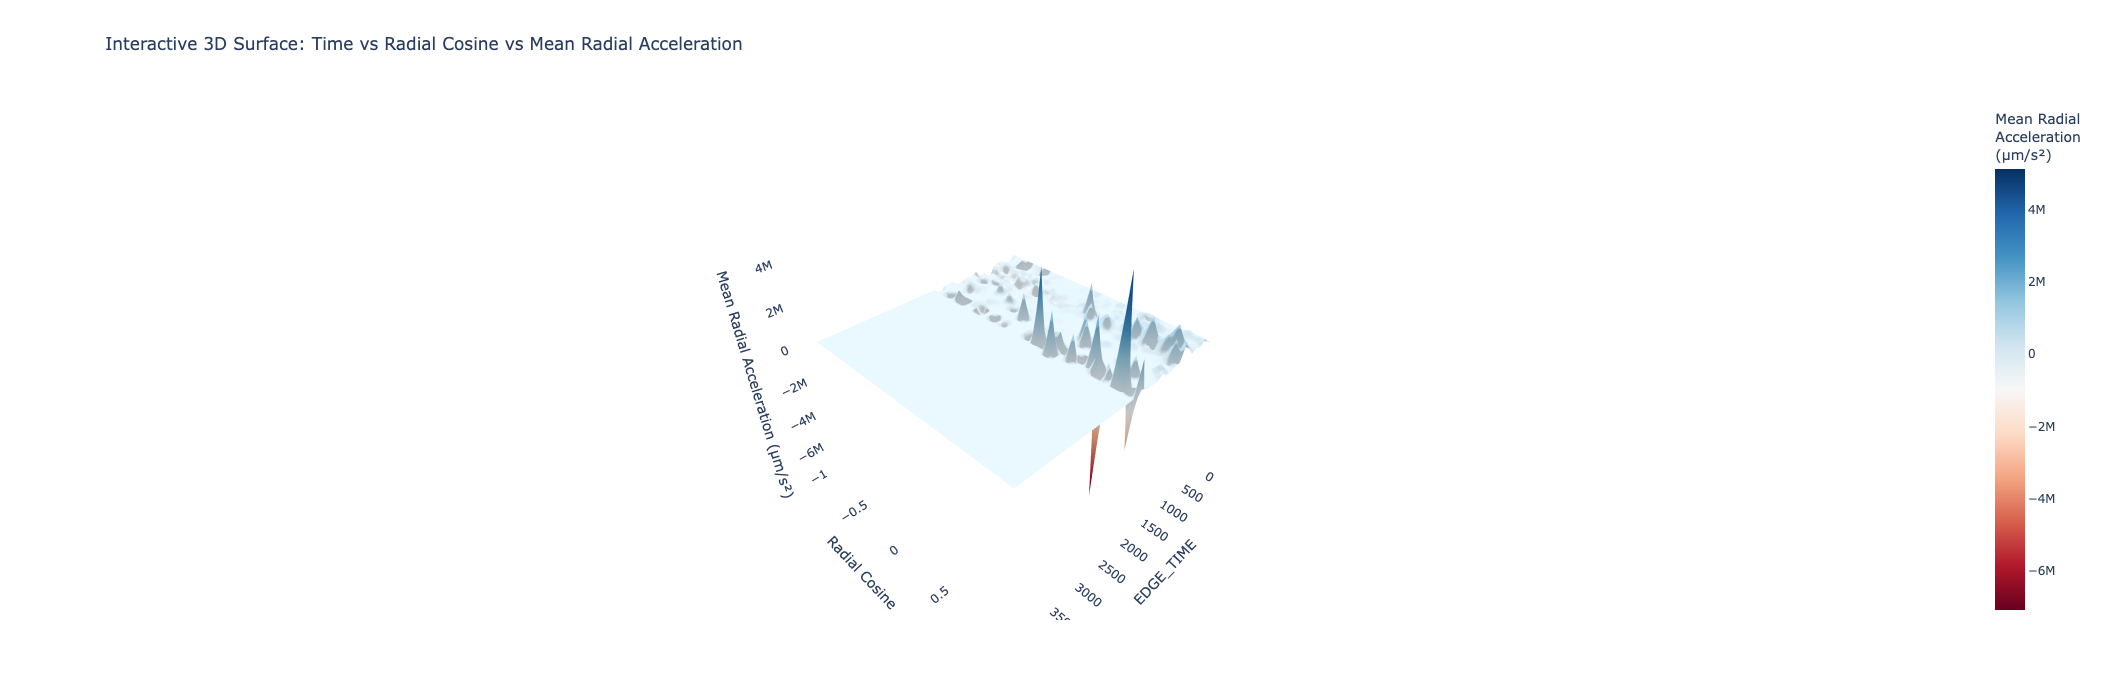

Time range: 1.0 to 3998.0
Radial cosine range: -1.000 to 1.000
Acceleration range: -1067756303.5822 to 1083773585.6623 μm/s²
Mean acceleration per bin range: -7088930.0082 to 5145513.2921 μm/s²


In [71]:
# Interactive 3D surface: Time vs Radial Cosine vs Mean Radial Acceleration
from utils import plot_interactive_acceleration_surface_3d

plot_interactive_acceleration_surface_3d(merged_sorted, n_time_bins=40, n_cos_bins=40)

# Mean Squared Displacement (MSD)

The following is the equation: $MSD(t) = <|r(t) - r(0)|^2>$

In [72]:
merged.columns

Index(['LABEL', 'TRACK_ID', 'SPOT_SOURCE_ID', 'SPOT_TARGET_ID', 'LINK_COST',
       'DIRECTIONAL_CHANGE_RATE', 'SPEED', 'DISPLACEMENT', 'EDGE_TIME',
       'EDGE_X_LOCATION', 'EDGE_Y_LOCATION', 'EDGE_Z_LOCATION',
       'MANUAL_EDGE_COLOR', 'POSITION_X_source', 'POSITION_Y_source',
       'POSITION_T_source', 'POSITION_X_target', 'POSITION_Y_target',
       'POSITION_T_target', 'V_x', 'V_y', 'VELOCITY', 'cosine', 'V_parallel',
       'V_orthogonal', 'time_bin', 'dx_centroid', 'dy_centroid', 'r_centroid',
       'r_safe', 'r_hat_x', 'r_hat_y', 't_hat_x', 't_hat_y', 'v_radial',
       'v_tangential', 'V_hat_x', 'V_hat_y', 'radial_cosine'],
      dtype='str')

In [73]:
merged.head()

,LABEL,TRACK_ID,SPOT_SOURCE_ID,SPOT_TARGET_ID,LINK_COST,DIRECTIONAL_CHANGE_RATE,SPEED,DISPLACEMENT,EDGE_TIME,EDGE_X_LOCATION,...,r_safe,r_hat_x,r_hat_y,t_hat_x,t_hat_y,v_radial,v_tangential,V_hat_x,V_hat_y,radial_cosine
0,ID8828 → ID8877,0,8877,8828,0.010385,2.168411,0.196958,0.196958,3361.0,282.778894,...,83.099876,-0.999774,-0.021253,0.021253,-0.999774,-0.035351,-0.033922,0.706659,0.707554,-0.721537
1,ID8854 → ID8828,0,8828,8854,0.589797,2.265405,0.364018,0.364018,3362.0,282.882576,...,82.998611,-0.999745,-0.022593,0.022593,-0.999745,-0.014947,0.089309,0.187303,-0.982302,-0.165062
2,ID8806 → ID8854,0,8854,8806,0.395159,2.969275,0.353423,0.353423,3363.0,283.028846,...,82.853345,-0.999732,-0.023143,0.023143,-0.999732,-0.057367,-0.066619,0.634817,0.772663,-0.652528
3,ID8900 → ID8806,0,8806,8900,1.611157,2.954880,0.222725,0.222725,3364.0,283.056624,...,82.824120,-0.999750,-0.022380,0.022380,-0.999750,0.042789,0.035195,-0.757901,-0.652370,0.772311
4,ID8822 → ID8900,0,8900,8822,0.410993,1.368130,0.268160,0.268160,3365.0,283.088312,...,82.792564,-0.999748,-0.022455,0.022455,-0.999748,-0.058491,-0.032070,0.865827,0.500343,-0.876844


### Track-Relative MSD (relative to track start)

For each track, we use the first position as r(0) and compute MSD relative to that starting point.

In [74]:
# Get initial positions per track (first edge's target position)
# Sort by track and time to ensure we get the first edge
merged_sorted_for_msd = merged.sort_values(['TRACK_ID', 'POSITION_T_source']).copy()

# Get first position of each track
initial_positions = merged_sorted_for_msd.groupby('TRACK_ID').first()[
    ['POSITION_X_source', 'POSITION_Y_source', 'POSITION_T_source']
].copy()
initial_positions.columns = ['x0_track', 'y0_track', 't0_track']

# Merge initial positions back into main dataframe
merged_sorted_for_msd = merged_sorted_for_msd.merge(
    initial_positions,
    left_on='TRACK_ID',
    right_index=True,
    how='left'
)

# Compute squared displacement from track start
merged_sorted_for_msd['dx_track'] = merged_sorted_for_msd['POSITION_X_target'] - merged_sorted_for_msd['x0_track']
merged_sorted_for_msd['dy_track'] = merged_sorted_for_msd['POSITION_Y_target'] - merged_sorted_for_msd['y0_track']

# Convert to math coordinates for Y
merged_sorted_for_msd['dy_track'] = merged_sorted_for_msd['dy_track'] * -1

# Squared displacement (in pixels, will convert later if needed)
merged_sorted_for_msd['MSD_track'] = merged_sorted_for_msd['dx_track']**2 + merged_sorted_for_msd['dy_track']**2

# Time relative to track start
merged_sorted_for_msd['t_rel'] = merged_sorted_for_msd['POSITION_T_target'] - merged_sorted_for_msd['t0_track']

print(f"Computed track-relative MSD for {merged_sorted_for_msd['TRACK_ID'].nunique()} tracks")
print(f"Time range (relative): {merged_sorted_for_msd['t_rel'].min():.1f} to {merged_sorted_for_msd['t_rel'].max():.1f}")
print(f"MSD range: {merged_sorted_for_msd['MSD_track'].min():.2f} to {merged_sorted_for_msd['MSD_track'].max():.2f} pixels²")

Computed track-relative MSD for 6234 tracks
Time range (relative): 1.0 to 2284.0
MSD range: 0.00 to 26434.32 pixels²


### Global Time-Zero MSD (relative to global t=0)

For all tracks, we use a global time zero (first frame in dataset) as the reference point.

In [75]:
# Find global time zero (minimum time across all tracks)
t_global_zero = merged['POSITION_T_target'].min()
print(f"Global time zero: {t_global_zero}")

# For each track, find position at or closest to global time zero
# If track doesn't exist at t_global_zero, use first available position
global_initial_positions = []

for track_id in merged['TRACK_ID'].unique():
    track_data = merged[merged['TRACK_ID'] == track_id].sort_values('POSITION_T_target')
    
    # Find position at or closest to global zero
    if track_data['POSITION_T_target'].min() <= t_global_zero:
        # Track exists at or before global zero, find closest
        closest_idx = (track_data['POSITION_T_target'] - t_global_zero).abs().idxmin()
        x0_global = track_data.loc[closest_idx, 'POSITION_X_target']
        y0_global = track_data.loc[closest_idx, 'POSITION_Y_target']
    else:
        # Track starts after global zero, use first position
        x0_global = track_data.iloc[0]['POSITION_X_target']
        y0_global = track_data.iloc[0]['POSITION_Y_target']
    
    global_initial_positions.append({
        'TRACK_ID': track_id,
        'x0_global': x0_global,
        'y0_global': y0_global
    })

global_init_df = pd.DataFrame(global_initial_positions).set_index('TRACK_ID')

# Merge into main dataframe
merged_sorted_for_msd = merged_sorted_for_msd.merge(
    global_init_df,
    left_on='TRACK_ID',
    right_index=True,
    how='left'
)

# Compute squared displacement from global zero
merged_sorted_for_msd['dx_global'] = merged_sorted_for_msd['POSITION_X_target'] - merged_sorted_for_msd['x0_global']
merged_sorted_for_msd['dy_global'] = merged_sorted_for_msd['POSITION_Y_target'] - merged_sorted_for_msd['y0_global']
# Convert to math coordinates for Y
merged_sorted_for_msd['dy_global'] = merged_sorted_for_msd['dy_global'] * -1

# Squared displacement
merged_sorted_for_msd['MSD_global'] = merged_sorted_for_msd['dx_global']**2 + merged_sorted_for_msd['dy_global']**2

# Absolute time
merged_sorted_for_msd['t_abs'] = merged_sorted_for_msd['POSITION_T_target']

print(f"Computed global MSD for {merged_sorted_for_msd['TRACK_ID'].nunique()} tracks")
print(f"Time range (absolute): {merged_sorted_for_msd['t_abs'].min():.1f} to {merged_sorted_for_msd['t_abs'].max():.1f}")
print(f"MSD range: {merged_sorted_for_msd['MSD_global'].min():.2f} to {merged_sorted_for_msd['MSD_global'].max():.2f} pixels²")

Global time zero: 1.0
Computed global MSD for 6234 tracks
Time range (absolute): 1.0 to 3999.0
MSD range: 0.00 to 26414.75 pixels²


In [76]:
# Convert MSD from pixels² to μm² (1 pixel = 3.731309 μm)
pixel_to_micron = 3.731309
merged_sorted_for_msd['MSD_track_um2'] = merged_sorted_for_msd['MSD_track'] * (pixel_to_micron**2)
merged_sorted_for_msd['MSD_global_um2'] = merged_sorted_for_msd['MSD_global'] * (pixel_to_micron**2)

# Compute RMSD (root mean squared displacement) in μm
merged_sorted_for_msd['RMSD_track'] = np.sqrt(merged_sorted_for_msd['MSD_track_um2'])
merged_sorted_for_msd['RMSD_global'] = np.sqrt(merged_sorted_for_msd['MSD_global_um2'])

print("Converted MSD to μm² and computed RMSD")

Converted MSD to μm² and computed RMSD


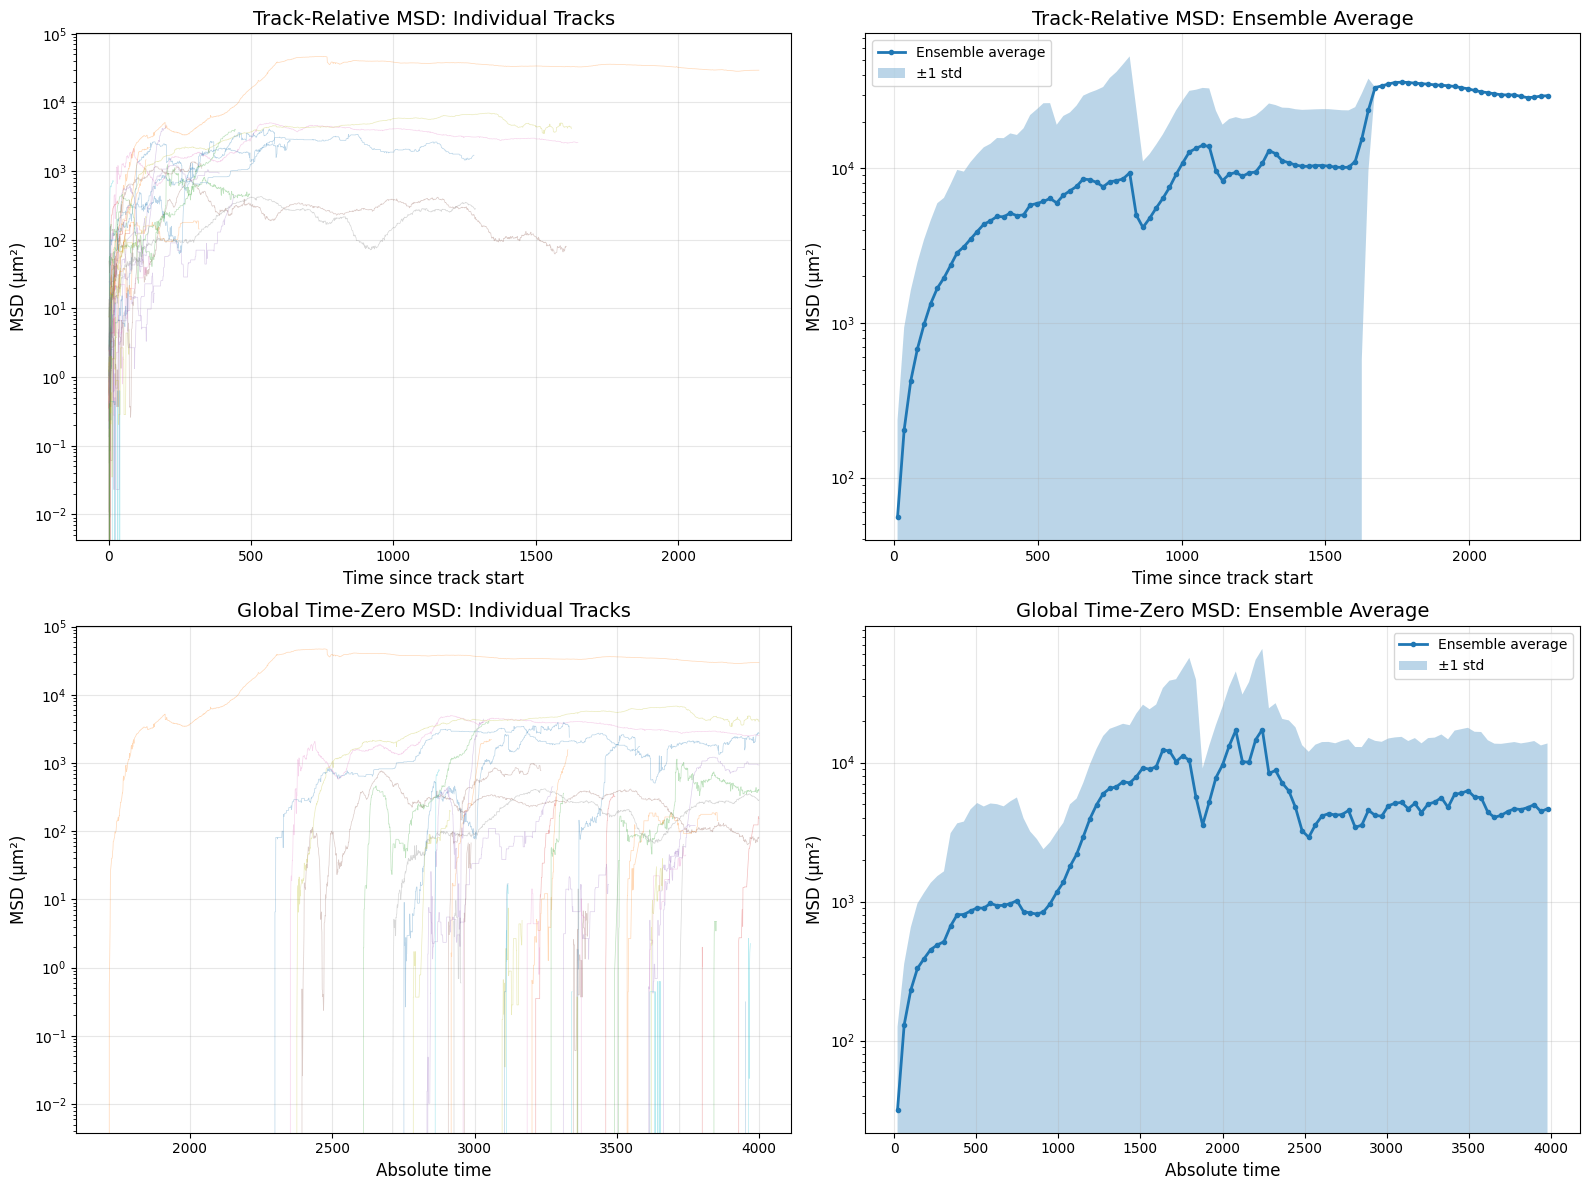

In [77]:
# Plot 1: Track-relative MSD - Individual tracks
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: MSD vs time (relative) - all tracks
ax1 = axes[0, 0]
for track_id in merged_sorted_for_msd['TRACK_ID'].unique()[:50]:  # Plot first 50 tracks for clarity
    track_data = merged_sorted_for_msd[merged_sorted_for_msd['TRACK_ID'] == track_id].sort_values('t_rel')
    ax1.plot(track_data['t_rel'], track_data['MSD_track_um2'], alpha=0.3, linewidth=0.5)

ax1.set_xlabel('Time since track start', fontsize=12)
ax1.set_ylabel('MSD (μm²)', fontsize=12)
ax1.set_title('Track-Relative MSD: Individual Tracks', fontsize=14)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Top-right: Ensemble average MSD (track-relative)
ax2 = axes[0, 1]
# Bin time and average MSD across tracks
time_bins = np.linspace(merged_sorted_for_msd['t_rel'].min(), merged_sorted_for_msd['t_rel'].max(), 100)
merged_sorted_for_msd['t_rel_bin'] = pd.cut(merged_sorted_for_msd['t_rel'], bins=time_bins)

ensemble_track = merged_sorted_for_msd.groupby('t_rel_bin')['MSD_track_um2'].agg(['mean', 'std', 'count']).reset_index()
ensemble_track['t_rel_center'] = ensemble_track['t_rel_bin'].apply(lambda x: x.mid)

ax2.plot(ensemble_track['t_rel_center'], ensemble_track['mean'], 'o-', linewidth=2, markersize=3, label='Ensemble average')
ax2.fill_between(
    ensemble_track['t_rel_center'],
    ensemble_track['mean'] - ensemble_track['std'],
    ensemble_track['mean'] + ensemble_track['std'],
    alpha=0.3,
    label='±1 std'
)
ax2.set_xlabel('Time since track start', fontsize=12)
ax2.set_ylabel('MSD (μm²)', fontsize=12)
ax2.set_title('Track-Relative MSD: Ensemble Average', fontsize=14)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom-left: Global MSD - Individual tracks
ax3 = axes[1, 0]
for track_id in merged_sorted_for_msd['TRACK_ID'].unique()[:50]:  # Plot first 50 tracks
    track_data = merged_sorted_for_msd[merged_sorted_for_msd['TRACK_ID'] == track_id].sort_values('t_abs')
    ax3.plot(track_data['t_abs'], track_data['MSD_global_um2'], alpha=0.3, linewidth=0.5)

ax3.set_xlabel('Absolute time', fontsize=12)
ax3.set_ylabel('MSD (μm²)', fontsize=12)
ax3.set_title('Global Time-Zero MSD: Individual Tracks', fontsize=14)
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

# Bottom-right: Ensemble average MSD (global)
ax4 = axes[1, 1]
# Bin absolute time and average MSD
time_bins_abs = np.linspace(merged_sorted_for_msd['t_abs'].min(), merged_sorted_for_msd['t_abs'].max(), 100)
merged_sorted_for_msd['t_abs_bin'] = pd.cut(merged_sorted_for_msd['t_abs'], bins=time_bins_abs)

ensemble_global = merged_sorted_for_msd.groupby('t_abs_bin')['MSD_global_um2'].agg(['mean', 'std', 'count']).reset_index()
ensemble_global['t_abs_center'] = ensemble_global['t_abs_bin'].apply(lambda x: x.mid)

ax4.plot(ensemble_global['t_abs_center'], ensemble_global['mean'], 'o-', linewidth=2, markersize=3, label='Ensemble average')
ax4.fill_between(
    ensemble_global['t_abs_center'],
    ensemble_global['mean'] - ensemble_global['std'],
    ensemble_global['mean'] + ensemble_global['std'],
    alpha=0.3,
    label='±1 std'
)
ax4.set_xlabel('Absolute time', fontsize=12)
ax4.set_ylabel('MSD (μm²)', fontsize=12)
ax4.set_title('Global Time-Zero MSD: Ensemble Average', fontsize=14)
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

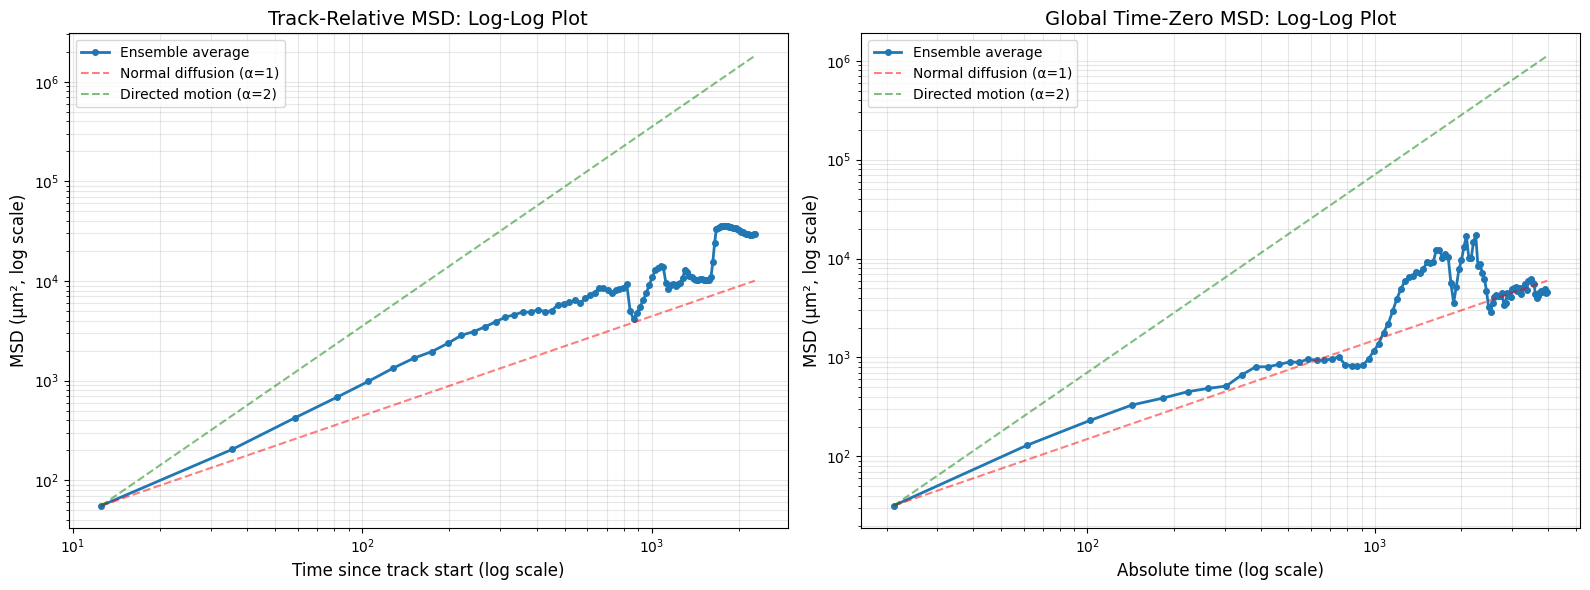

In [78]:
# Log-log plots to identify power-law behavior (MSD ∝ t^α)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Track-relative MSD (log-log)
ax1 = axes[0]
# Filter out zero/negative times and MSD
ensemble_track['t_rel_center'] = pd.to_numeric(ensemble_track['t_rel_center'], errors='coerce')
valid_track = ensemble_track[
    (ensemble_track['t_rel_center'] > 0) & 
    (ensemble_track['mean'] > 0)
].copy()

ax1.loglog(valid_track['t_rel_center'], valid_track['mean'], 'o-', linewidth=2, markersize=4, label='Ensemble average')
ax1.set_xlabel('Time since track start (log scale)', fontsize=12)
ax1.set_ylabel('MSD (μm², log scale)', fontsize=12)
ax1.set_title('Track-Relative MSD: Log-Log Plot', fontsize=14)
ax1.grid(True, alpha=0.3, which='both')

# Add reference lines for different diffusion regimes
if len(valid_track) > 0:
    t_ref = valid_track['t_rel_center'].iloc[0]
    msd_ref = valid_track['mean'].iloc[0]
    
    # Normal diffusion: MSD ∝ t (slope = 1)
    t_line = np.linspace(t_ref, valid_track['t_rel_center'].max(), 100)
    msd_line1 = msd_ref * (t_line / t_ref)**1
    ax1.loglog(t_line, msd_line1, 'r--', alpha=0.5, label='Normal diffusion (α=1)')
    
    # Directed motion: MSD ∝ t² (slope = 2)
    msd_line2 = msd_ref * (t_line / t_ref)**2
    ax1.loglog(t_line, msd_line2, 'g--', alpha=0.5, label='Directed motion (α=2)')

ax1.legend()

# Right: Global MSD (log-log)
ax2 = axes[1]
ensemble_global['t_abs_center'] = pd.to_numeric(ensemble_global['t_abs_center'], errors='coerce')
valid_global = ensemble_global[
    (ensemble_global['t_abs_center'] > 0) & 
    (ensemble_global['mean'] > 0)
].copy()

ax2.loglog(valid_global['t_abs_center'], valid_global['mean'], 'o-', linewidth=2, markersize=4, label='Ensemble average')
ax2.set_xlabel('Absolute time (log scale)', fontsize=12)
ax2.set_ylabel('MSD (μm², log scale)', fontsize=12)
ax2.set_title('Global Time-Zero MSD: Log-Log Plot', fontsize=14)
ax2.grid(True, alpha=0.3, which='both')

# Add reference lines
if len(valid_global) > 0:
    t_ref = valid_global['t_abs_center'].iloc[0]
    msd_ref = valid_global['mean'].iloc[0]
    
    t_line = np.linspace(t_ref, valid_global['t_abs_center'].max(), 100)
    msd_line1 = msd_ref * (t_line / t_ref)**1
    ax2.loglog(t_line, msd_line1, 'r--', alpha=0.5, label='Normal diffusion (α=1)')
    
    msd_line2 = msd_ref * (t_line / t_ref)**2
    ax2.loglog(t_line, msd_line2, 'g--', alpha=0.5, label='Directed motion (α=2)')

ax2.legend()

plt.tight_layout()
plt.show()

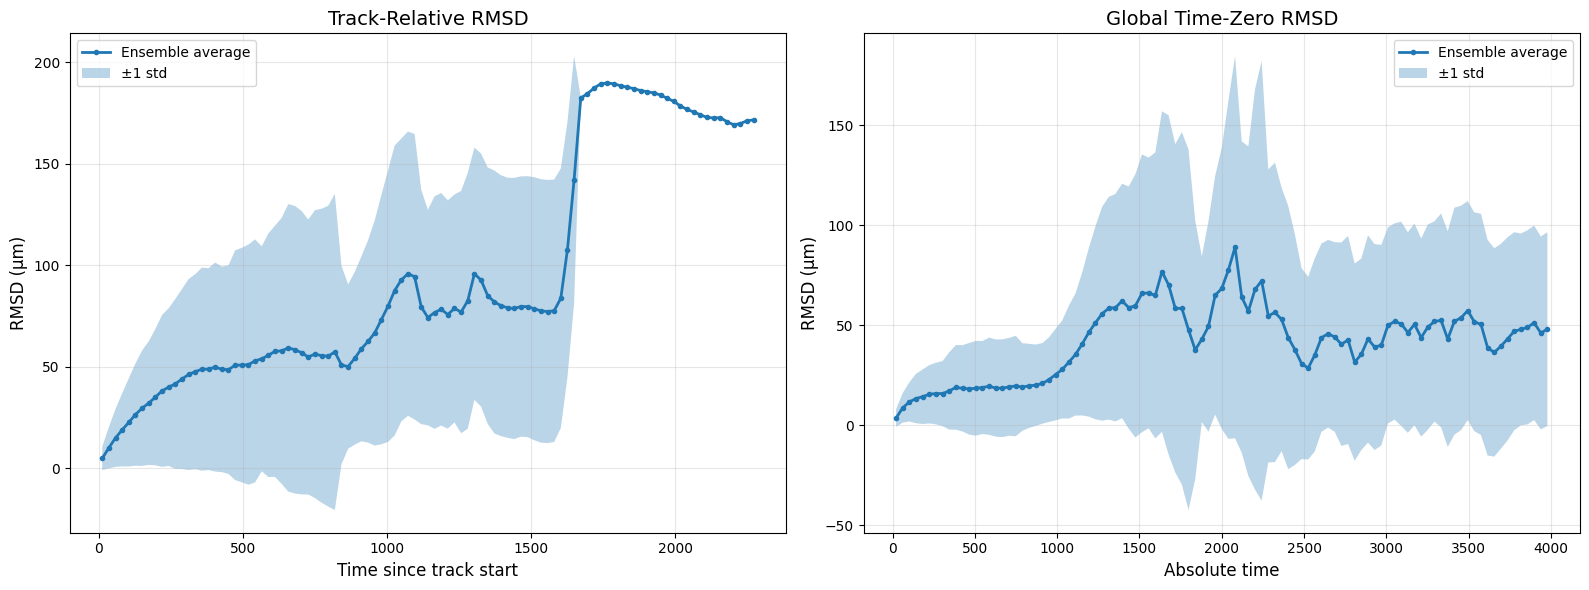

In [79]:
# RMSD plots (easier to interpret - same units as position)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Track-relative RMSD
ax1 = axes[0]
ensemble_track_rmsd = merged_sorted_for_msd.groupby('t_rel_bin')['RMSD_track'].agg(['mean', 'std']).reset_index()
ensemble_track_rmsd['t_rel_center'] = ensemble_track_rmsd['t_rel_bin'].apply(lambda x: x.mid)

ax1.plot(ensemble_track_rmsd['t_rel_center'], ensemble_track_rmsd['mean'], 'o-', linewidth=2, markersize=3, label='Ensemble average')
ax1.fill_between(
    ensemble_track_rmsd['t_rel_center'],
    ensemble_track_rmsd['mean'] - ensemble_track_rmsd['std'],
    ensemble_track_rmsd['mean'] + ensemble_track_rmsd['std'],
    alpha=0.3,
    label='±1 std'
)
ax1.set_xlabel('Time since track start', fontsize=12)
ax1.set_ylabel('RMSD (μm)', fontsize=12)
ax1.set_title('Track-Relative RMSD', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Global RMSD
ax2 = axes[1]
ensemble_global_rmsd = merged_sorted_for_msd.groupby('t_abs_bin')['RMSD_global'].agg(['mean', 'std']).reset_index()
ensemble_global_rmsd['t_abs_center'] = ensemble_global_rmsd['t_abs_bin'].apply(lambda x: x.mid)

ax2.plot(ensemble_global_rmsd['t_abs_center'], ensemble_global_rmsd['mean'], 'o-', linewidth=2, markersize=3, label='Ensemble average')
ax2.fill_between(
    ensemble_global_rmsd['t_abs_center'],
    ensemble_global_rmsd['mean'] - ensemble_global_rmsd['std'],
    ensemble_global_rmsd['mean'] + ensemble_global_rmsd['std'],
    alpha=0.3,
    label='±1 std'
)
ax2.set_xlabel('Absolute time', fontsize=12)
ax2.set_ylabel('RMSD (μm)', fontsize=12)
ax2.set_title('Global Time-Zero RMSD', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
# Summary statistics
print("="*60)
print("MSD Analysis Summary")
print("="*60)

print(f"\nTrack-Relative MSD:")
print(f"  Number of tracks: {merged_sorted_for_msd['TRACK_ID'].nunique()}")
print(f"  Time range (relative): {merged_sorted_for_msd['t_rel'].min():.1f} to {merged_sorted_for_msd['t_rel'].max():.1f}")
print(f"  MSD range: {merged_sorted_for_msd['MSD_track_um2'].min():.2f} to {merged_sorted_for_msd['MSD_track_um2'].max():.2f} μm²")
print(f"  RMSD range: {merged_sorted_for_msd['RMSD_track'].min():.2f} to {merged_sorted_for_msd['RMSD_track'].max():.2f} μm")

print(f"\nGlobal Time-Zero MSD:")
print(f"  Global time zero: {t_global_zero:.1f}")
print(f"  Time range (absolute): {merged_sorted_for_msd['t_abs'].min():.1f} to {merged_sorted_for_msd['t_abs'].max():.1f}")
print(f"  MSD range: {merged_sorted_for_msd['MSD_global_um2'].min():.2f} to {merged_sorted_for_msd['MSD_global_um2'].max():.2f} μm²")
print(f"  RMSD range: {merged_sorted_for_msd['RMSD_global'].min():.2f} to {merged_sorted_for_msd['RMSD_global'].max():.2f} μm")

# Compute power-law exponent (if linear in log-log, fit slope)
if len(valid_track) > 5:
    from scipy import stats
    log_t = np.log(valid_track['t_rel_center'].values)
    log_msd = np.log(valid_track['mean'].values)
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_t, log_msd)
    print(f"\nTrack-Relative Power-Law Exponent (α):")
    print(f"  α = {slope:.3f} ± {std_err:.3f}")
    print(f"  R² = {r_value**2:.3f}")
    print(f"  Interpretation: {'Directed motion' if slope > 1.5 else 'Normal diffusion' if slope > 0.8 else 'Subdiffusion'}")

if len(valid_global) > 5:
    log_t = np.log(valid_global['t_abs_center'].values)
    log_msd = np.log(valid_global['mean'].values)
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_t, log_msd)
    print(f"\nGlobal Power-Law Exponent (α):")
    print(f"  α = {slope:.3f} ± {std_err:.3f}")
    print(f"  R² = {r_value**2:.3f}")
    print(f"  Interpretation: {'Directed motion' if slope > 1.5 else 'Normal diffusion' if slope > 0.8 else 'Subdiffusion'}")

MSD Analysis Summary

Track-Relative MSD:
  Number of tracks: 6234
  Time range (relative): 1.0 to 2284.0
  MSD range: 0.00 to 368036.25 μm²
  RMSD range: 0.00 to 606.66 μm

Global Time-Zero MSD:
  Global time zero: 1.0
  Time range (absolute): 1.0 to 3999.0
  MSD range: 0.00 to 367763.71 μm²
  RMSD range: 0.00 to 606.44 μm

Track-Relative Power-Law Exponent (α):
  α = 1.115 ± 0.036
  R² = 0.908
  Interpretation: Normal diffusion

Global Power-Law Exponent (α):
  α = 0.986 ± 0.062
  R² = 0.721
  Interpretation: Normal diffusion
